In [1]:
import pandas as pd

# The file appears to be space/whitespace separated
# Using delimiter=r'\s+' to handle multiple spaces/tabs
info = pd.read_csv('info.txt', delimiter=r'\s+')

# Filter columns: keep 'runid' and columns starting with 'ocn.' but exclude 'ocean_fw'
ocn_columns = [col for col in info.columns if col.startswith('ocn.')]
columns_to_keep = ['runid'] + ocn_columns

# Remove 'ocean_fw' if it exists in the selected columns
if 'ocn.l_noise_fw' in columns_to_keep:
    columns_to_keep.remove('ocn.l_noise_fw')

# Select only the desired columns
params = info[columns_to_keep]

# Display the results
print("Original shape:", info.shape)
print("Filtered shape:", params.shape)
print("\nKept columns:")
print(params.columns.tolist())
print("\nFirst 5 rows of filtered data:")
print(params.head())

Original shape: (500, 8)
Filtered shape: (500, 7)

Kept columns:
['runid', 'ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max', 'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max']

First 5 rows of filtered data:
   runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  ocn.diff_iso  \
0      1          0.000007           3.140315       0.001005   1311.247475   
1      2          0.000014           3.387432       0.001050   1653.858523   
2      3          0.000012           2.877069       0.000695   1704.188023   
3      4          0.000012           2.615323       0.001058   1453.578268   
4      5          0.000007           3.177072       0.000827   1553.112746   

   ocn.diff_gm  ocn.diff_dia_max  
0  1269.062288          0.000137  
1  1819.713492          0.000160  
2  1445.417076          0.000125  
3  1573.687262          0.000138  
4  1256.308971          0.000118  


In [2]:
# Basic descriptive statistics
print("\nDescriptive Statistics:")
print(params.describe())


Descriptive Statistics:
            runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  \
count  500.000000        500.000000         500.000000     500.000000   
mean   250.500000          0.000010           2.999944       0.001000   
std    144.481833          0.000002           0.231396       0.000231   
min      1.000000          0.000006           2.601582       0.000600   
25%    125.750000          0.000008           2.799612       0.000800   
50%    250.500000          0.000010           2.999033       0.001000   
75%    375.250000          0.000012           3.200231       0.001200   
max    500.000000          0.000014           3.398624       0.001400   

       ocn.diff_iso  ocn.diff_gm  ocn.diff_dia_max  
count    500.000000   500.000000        500.000000  
mean    1499.297979  1500.325846          0.000150  
std      230.841389   231.311277          0.000023  
min     1100.080860  1100.792227          0.000110  
25%     1299.866116  1300.397590          0.000130  

In [3]:
import xarray as xr
import matplotlib.pyplot as plt
import os

# Find all ocn_ts.nc files
model_files = []
run_labels = []
missing_ids=[]
for run_id in range(1, 501):
    file_path = f"{run_id}/ocn_ts.nc"
    if os.path.exists(file_path):
        model_files.append(file_path)
        run_labels.append(str(run_id))
    else:
        missing_ids.append(run_id)
        model_files.append(None) 
drop_ids = [idx-1 for idx in missing_ids]
print(drop_ids)
# Remove rows with indices in missing_ids
# params = params.drop(index=drop_ids)


# Descriptive statistics
print("\nDescriptive Statistics:")
print(params.describe())



[185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201]

Descriptive Statistics:
            runid  ocn.diff_dia_min  ocn.drag_topo_fac  ocn.slope_max  \
count  500.000000        500.000000         500.000000     500.000000   
mean   250.500000          0.000010           2.999944       0.001000   
std    144.481833          0.000002           0.231396       0.000231   
min      1.000000          0.000006           2.601582       0.000600   
25%    125.750000          0.000008           2.799612       0.000800   
50%    250.500000          0.000010           2.999033       0.001000   
75%    375.250000          0.000012           3.200231       0.001200   
max    500.000000          0.000014           3.398624       0.001400   

       ocn.diff_iso  ocn.diff_gm  ocn.diff_dia_max  
count    500.000000   500.000000        500.000000  
mean    1499.297979  1500.325846          0.000150  
std      230.841389   231.311277          0.000023  
min     1100.080860

In [4]:
import numpy as np
from scipy.stats import gaussian_kde
from scipy.signal import welch
from sklearn.cluster import KMeans

def detect_stadials_adaptive(amoc_smooth, method='bimodal_gap', offset=2.5):
    if method == 'percentile':
        return np.percentile(amoc_smooth, 25)

    elif method == 'bimodal_gap':
        hist, edges = np.histogram(amoc_smooth, bins=50, density=True)
        bin_centers = (edges[:-1] + edges[1:]) / 2
        mid_range = (len(hist) // 4, 3 * len(hist) // 4)
        local_min_idx = mid_range[0] + np.argmin(hist[mid_range[0]:mid_range[1]])
        return bin_centers[local_min_idx]

    elif method == 'clustering':
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        kmeans.fit(amoc_smooth.reshape(-1, 1))
        centers = kmeans.cluster_centers_.flatten()
        low, high = np.min(centers), np.max(centers)
        threshold = low + offset
        if threshold > high:
            threshold = np.mean(centers)
        return threshold

    else:
        raise ValueError(f"Unknown method: {method}")

from scipy import signal

def lowpass_filter(data, cutoff_years, dt=1.0):
    """
    Apply a lowpass Butterworth filter to time series data.
    
    Parameters:
    -----------
    data : array
        Input time series
    cutoff_years : float
        Cutoff period in years (e.g., 100 means preserve variations longer than 100 years)
    dt : float
        Time step in years (default 1.0 for yearly data)
    
    Returns:
    --------
    filtered_data : array
        Lowpass filtered time series
    """
    # Convert cutoff period to frequency
    cutoff_freq = 1.0 / cutoff_years  # cycles per year
    nyquist_freq = 1.0 / (2.0 * dt)   # Nyquist frequency
    normalized_cutoff = cutoff_freq / nyquist_freq
    
    # Design Butterworth filter (order=4 is a good default)
    b, a = signal.butter(4, normalized_cutoff, btype='low', analog=False)
    
    # Apply filter (filtfilt does forward-backward filtering to avoid phase shift)
    filtered_data = signal.filtfilt(b, a, data)
    
    return filtered_data


# Experiment with bimodal parameters instead of PCA

In [5]:
from scipy.stats import gaussian_kde, skew, kurtosis
from scipy.signal import welch
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans

import numpy as np
from scipy.stats import gaussian_kde
from scipy.signal import welch
from sklearn.mixture import GaussianMixture

def compute_summary_stats(
        amoc_data, time_data,
        threshold=None,
        smooth_win=0,
        grid_points=100,
        use_gmm=True, n_components=3,
        psd_bins_count=10,
        quantiles=[0.1, 0.5, 0.9],
        remove_spinup=True, spinup_fraction=0.0,
        adaptive_threshold=True, threshold_method='clustering'
    ):
    
    amoc_data = np.asarray(amoc_data)
    time_data = np.asarray(time_data)

    # ---------------------------------------------
    # Remove spinup
    # ---------------------------------------------
    if remove_spinup:
        start = int(len(amoc_data) * spinup_fraction)
        amoc_data = amoc_data[start:]
        time_data = time_data[start:]
        time_data = time_data - time_data[0]

    # ---------------------------------------------
    # 1. Basic statistics
    # ---------------------------------------------
    mean_val = float(np.mean(amoc_data))
    std_val  = float(np.std(amoc_data))
    quantile_vals = np.quantile(amoc_data, quantiles)

    # ---------------------------------------------
    # 2. PDF (GMM or KDE)
    # ---------------------------------------------
    x_grid = np.linspace(amoc_data.min(), amoc_data.max(), grid_points)

    if use_gmm:
        X = amoc_data.reshape(-1, 1)
        gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)
        gmm.fit(X)

        pdf_vals = np.exp(gmm.score_samples(x_grid.reshape(-1, 1)))

        gmm_params = np.ravel(
            np.column_stack([
                gmm.weights_,
                gmm.means_.flatten(),
                np.sqrt(gmm.covariances_.flatten())
            ])
        )

    else:
        kde = gaussian_kde(amoc_data)
        pdf_vals = kde(x_grid)
        pdf_vals /= np.trapezoid(pdf_vals, x_grid)
        gmm_params = None

    # ---------------------------------------------
    # 3. Smoothing for stadial detection
    # ---------------------------------------------
    if smooth_win > 1:
        kernel = np.ones(smooth_win) / smooth_win
        amoc_smooth = np.convolve(amoc_data, kernel, mode='same')
    else:
        amoc_smooth = amoc_data.copy()

    # ---------------------------------------------
    # 4. Adaptive or fixed threshold
    # ---------------------------------------------
    if adaptive_threshold:
        threshold_val = detect_stadials_adaptive(amoc_smooth, method=threshold_method)
    else:
        threshold_val = np.percentile(amoc_smooth, 25) if threshold is None else threshold

    # ---------------------------------------------
    # 5. Stadial start/stop detection
    # ---------------------------------------------
    is_stadial = amoc_smooth < threshold_val
    transitions = np.diff(is_stadial.astype(int))

    starts = np.where(transitions == 1)[0] + 1
    ends   = np.where(transitions == -1)[0] + 1

    if is_stadial[0]:  starts = np.insert(starts, 0, 0)
    if is_stadial[-1]: ends   = np.append(ends, len(amoc_smooth))

    # Ensure match
    n_stadials = min(len(starts), len(ends))
    starts = starts[:n_stadials]
    ends   = ends[:n_stadials]

    stadial_durations = time_data[ends - 1] - time_data[starts]
    avg_stadial_duration = float(np.mean(stadial_durations)) if len(stadial_durations) else 0.0

    waiting_times = np.diff(time_data[starts]) if len(starts) > 1 else np.array([])
    avg_waiting_time = float(np.mean(waiting_times)) if len(waiting_times) else 0.0

    # ---------------------------------------------
    # 6. Amplitude calculation
    # ---------------------------------------------
    inter_max = []
    stad_min = []

    for i in range(n_stadials - 1):
        seg_stad = amoc_smooth[starts[i]:ends[i]]
        seg_inter = amoc_smooth[ends[i]:starts[i+1]]
        if len(seg_stad): stad_min.append(seg_stad.min())
        if len(seg_inter): inter_max.append(seg_inter.max())

    amplitude_vals = np.array(inter_max) - np.array(stad_min)
    avg_amplitude = float(np.mean(amplitude_vals)) if len(amplitude_vals) else 0.0

    # ---------------------------------------------
    # 7. PSD bins
    # ---------------------------------------------
    f, Pxx = welch(amoc_data, fs=1.0, nperseg=min(256, len(amoc_data)))
    psd_bins = np.log(Pxx[:psd_bins_count])

    # ---------------------------------------------
    # 8. Final return dict (your structure)
    # ---------------------------------------------
    return {
        'mean': mean_val,
        'std': std_val,
        'quantiles': quantile_vals,

        'pdf': pdf_vals,
        'x_grid': x_grid,

        'threshold': threshold_val,

        'n_stadials': n_stadials,
        'stadial_starts': starts,
        'stadial_ends': ends,

        'avg_stadial_duration': avg_stadial_duration,
        'stadial_durations': stadial_durations,

        'avg_waiting_time': avg_waiting_time,
        'waiting_times': waiting_times,

        'avg_amplitude': avg_amplitude,

        'psd_bins': psd_bins,

        'gmm_params': gmm_params
    }


In [6]:
import xarray as xr
# Default run - compute BOTH KDE and GMM stats
default_file = "../default_long_run/ocn_ts.nc"
ds_default = xr.open_dataset(default_file)
amoc_default = ds_default.amoc26N.values
time_default = ds_default.time.values
ds_default.close()

# Apply lowpass filter
amoc_default_filtered = lowpass_filter(amoc_default, cutoff_years=100)

# Compute with KDE
default_stats_kde = compute_summary_stats(amoc_default_filtered, time_default, use_gmm=False)
# Compute with GMM
default_stats_gmm = compute_summary_stats(amoc_default_filtered, time_default, use_gmm=True, n_components=3)

threshold = default_stats_kde['threshold']  # Use same threshold for all

# Print GMM parameters
print("Default GMM Parameters [w₁, μ₁, σ₁, μ₂, σ₂]:", default_stats_gmm['gmm_params'])

# Ensemble runs - compute BOTH KDE and GMM
ensemble_stats_kde = []
ensemble_stats_gmm = []

# Ensemble runs
apply_filter = True
ensemble_stats = []
for file in model_files:
    if file:
        ds = xr.open_dataset(file)
        amoc = ds.amoc26N.values
        time = ds.time.values
        ds.close()
        
        # Apply same optional lowpass filter
        if apply_filter:
            amoc_processed = lowpass_filter(amoc, cutoff_years=100)
        else:
            amoc_processed = amoc
        
        # Compute with KDE
        stats_kde = compute_summary_stats(amoc_processed, time, use_gmm=False)
        ensemble_stats_kde.append(stats_kde)
        
        # Compute with GMM
        stats_gmm = compute_summary_stats(amoc_processed, time, use_gmm=True, n_components=3)
        ensemble_stats_gmm.append(stats_gmm)

    else: 
        ensemble_stats_gmm.append(None)
        ensemble_stats_kde.append(None)


Default GMM Parameters [w₁, μ₁, σ₁, μ₂, σ₂]: [ 0.21985737 17.52896939  2.39219492  0.117067   25.38991325  2.31326066
  0.66307564  8.71348105  1.32326863]


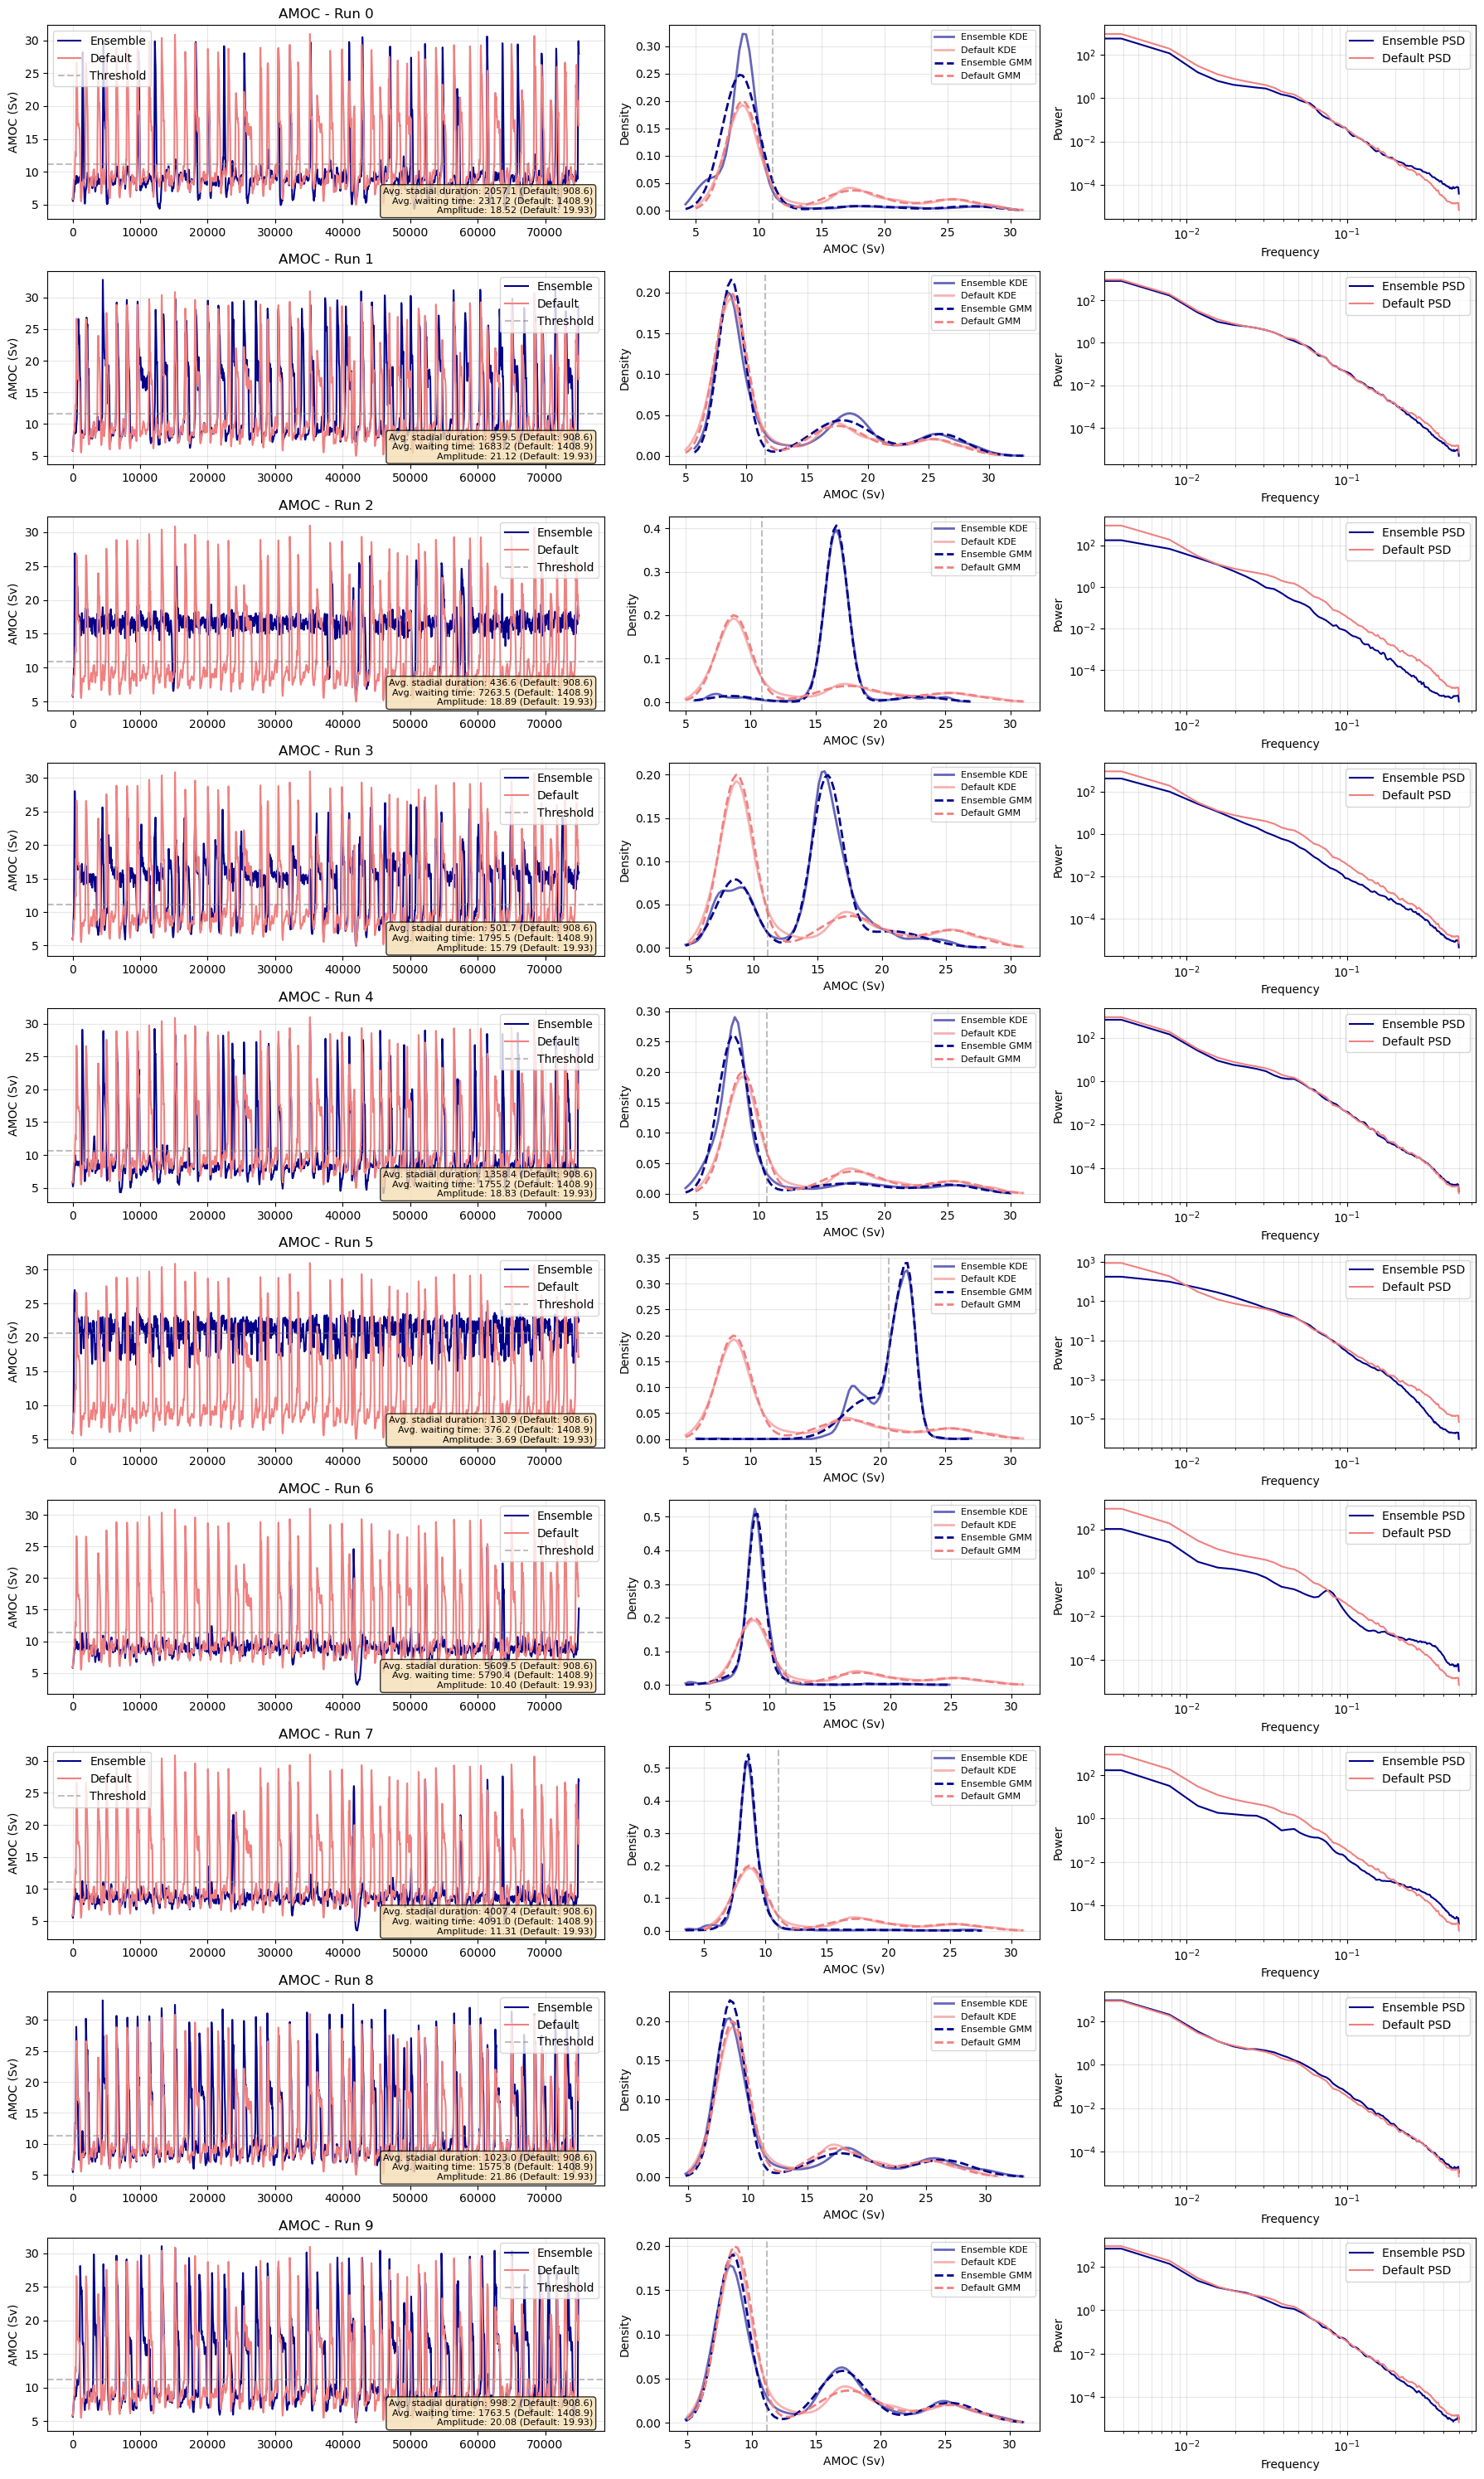

In [7]:
n_runs = 10
fig, axes = plt.subplots(n_runs, 3, figsize=(18, 3*n_runs), gridspec_kw={'width_ratios': [3, 2, 2]})

# Handle single run
if n_runs == 1:
    axes = [axes]

for i, file in enumerate(model_files[:n_runs]):
    ds = xr.open_dataset(file)
    amoc = ds.amoc26N.values
    ds.close()
    
    # Apply same filter as in your analysis
    amoc_filtered = lowpass_filter(amoc, cutoff_years=100)
    
    # Get both KDE and GMM stats for this run
    stats_kde = ensemble_stats_kde[i]
    stats_gmm = ensemble_stats_gmm[i]
    
    # ----------------------------
    # 1. Time series plot
    # ----------------------------
    axes[i][0].plot(amoc_filtered, color='darkblue', label='Ensemble')
    axes[i][0].plot(amoc_default_filtered, color='lightcoral', label='Default')
    axes[i][0].axhline(stats_kde['threshold'], color='gray', linestyle='--', alpha=0.5, label='Threshold')
    axes[i][0].set_ylabel('AMOC (Sv)')
    axes[i][0].set_title(f'AMOC - Run {i}')
    axes[i][0].legend()
    axes[i][0].grid(alpha=0.3)
    
    # Add summary stats text
    axes[i][0].text(
        0.98, 0.02,
        f"Avg. stadial duration: {stats_kde['avg_stadial_duration']:.1f} (Default: {default_stats_kde['avg_stadial_duration']:.1f})\n"
        f"Avg. waiting time: {stats_kde['avg_waiting_time']:.1f} (Default: {default_stats_kde['avg_waiting_time']:.1f})\n"
        f"Amplitude: {stats_kde['avg_amplitude']:.2f} (Default: {default_stats_kde['avg_amplitude']:.2f})",
        transform=axes[i][0].transAxes,
        fontsize=8, verticalalignment='bottom', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )
    
    # ----------------------------
    # 2. PDF plot - KDE + GMM
    # ----------------------------
    # Plot KDE PDFs (solid lines)
    axes[i][1].plot(stats_kde['x_grid'], stats_kde['pdf'], color='darkblue', 
                    linestyle='-', alpha=0.6, linewidth=2, label='Ensemble KDE')
    axes[i][1].plot(default_stats_kde['x_grid'], default_stats_kde['pdf'], color='lightcoral', 
                    linestyle='-', alpha=0.6, linewidth=2, label='Default KDE')
    
    # Plot GMM PDFs (dashed lines) - directly from stats['pdf']
    axes[i][1].plot(stats_gmm['x_grid'], stats_gmm['pdf'], color='darkblue', 
                    linestyle='--', linewidth=2, label='Ensemble GMM')
    axes[i][1].plot(default_stats_gmm['x_grid'], default_stats_gmm['pdf'], color='lightcoral', 
                    linestyle='--', linewidth=2, label='Default GMM')
    
    axes[i][1].axvline(stats_kde['threshold'], color='gray', linestyle='--', alpha=0.5)
    axes[i][1].set_ylabel('Density')
    axes[i][1].set_xlabel('AMOC (Sv)')
    axes[i][1].legend(fontsize=8, loc='best')
    axes[i][1].grid(alpha=0.3)
    
    '''
    # Add GMM parameters as text (for 3 components: 9 parameters)
    gmm_params = stats_gmm['gmm_params']
    w1, mu1, sig1 = gmm_params[0], gmm_params[1], gmm_params[2]
    w2, mu2, sig2 = gmm_params[3], gmm_params[4], gmm_params[5]
    w3, mu3, sig3 = gmm_params[6], gmm_params[7], gmm_params[8]
    
    axes[i][1].text(
        0.02, 0.98,
        f"GMM (3 comp):\n"
        f"w₁={w1:.2f}, μ₁={mu1:.1f}, σ₁={sig1:.1f}\n"
        f"w₂={w2:.2f}, μ₂={mu2:.1f}, σ₂={sig2:.1f}\n"
        f"w₃={w3:.2f}, μ₃={mu3:.1f}, σ₃={sig3:.1f}",
        transform=axes[i][1].transAxes,
        fontsize=7, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7)
    )
    '''
    
    # ----------------------------
    # 3. PSD plot
    # ----------------------------
    fs = 1.0  # sampling frequency (adjust if needed)
    f, Pxx = welch(amoc, fs=fs, nperseg=min(256, len(amoc)))
    f_default, Pxx_default = welch(amoc_default, fs=fs, nperseg=min(256, len(amoc_default)))
    
    axes[i][2].plot(f, Pxx, color='darkblue', label='Ensemble PSD')
    axes[i][2].plot(f_default, Pxx_default, color='lightcoral', label='Default PSD')
    axes[i][2].set_xscale('log')
    axes[i][2].set_yscale('log')
    axes[i][2].set_xlabel('Frequency')
    axes[i][2].set_ylabel('Power')
    axes[i][2].legend()
    axes[i][2].grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

# Predict Gmm parameters

In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from scipy.stats import norm

class GPEmulatorGMM:
    def __init__(self, n_components=3, kernel=None, scaler_X=None, scaler_y=None):
        """
        GP emulator that predicts GMM parameters directly.
        
        Parameters
        ----------
        n_components : int
            Number of Gaussian components in the mixture
        kernel : GP kernel
            Kernel for the GP. If None, uses RBF + WhiteKernel
        scaler_X : scaler for input features
            If None, uses StandardScaler
        scaler_y : scaler for output features  
            If None, uses StandardScaler
        """
        self.n_components = n_components
        self.kernel = kernel if kernel is not None else RBF(1.0) + WhiteKernel(1e-6)
        self.scaler_X = scaler_X if scaler_X is not None else StandardScaler()
        self.scaler_y = scaler_y if scaler_y is not None else StandardScaler()
        self.gp_model = None
        self.is_fitted = False
        self.pdf_xpoints = None
        self.n_gmm_params = 3 * n_components  # w, mu, sigma for each component
        
    def fit(self, X, Y, gmm_params):
        """
        Fit the GP emulator.
        
        Parameters
        ----------
        X : array-like, shape (n_samples, n_input_parameters)
            Input parameters (e.g., climate model parameters)
        Y : array-like, shape (n_samples, n_other_summary_stats)
            Other summary statistics
        gmm_params : array-like, shape (n_samples, 3*n_components)
            GMM parameters for each sample: [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ...]
            Format: weight, mean, std for each component
        """
        # Validate input dimensions
        expected_params = 3 * self.n_components
        if gmm_params.shape[1] != expected_params:
            raise ValueError(
                f"Expected {expected_params} GMM parameters for {self.n_components} components, "
                f"got {gmm_params.shape[1]}"
            )
        
        self.n_gmm_params = gmm_params.shape[1]
        
        # Combine GMM parameters and other summary stats
        Y_full = np.hstack([gmm_params, Y])
        
        # Scale
        X_scaled = self.scaler_X.fit_transform(X)
        Y_scaled = self.scaler_y.fit_transform(Y_full)
        
        # Fit single multi-output GP
        self.gp_model = GaussianProcessRegressor(
            kernel=self.kernel, 
            normalize_y=True,
            n_restarts_optimizer=3
        )
        self.gp_model.fit(X_scaled, Y_scaled)
        self.is_fitted = True
        
    def predict(self, X_new, return_std=True):
        """
        Predict GMM parameters and other summary stats for new inputs.
        
        Returns
        -------
        gmm_params_pred : array, shape (n_samples, 3*n_components)
            Predicted GMM parameters [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ...]
        Y_pred : array, shape (n_samples, n_other_summary_stats)
            Predicted other summary statistics
        gmm_params_std : array, optional, shape (n_samples, 3*n_components)
            Uncertainty in GMM parameters
        Y_std : array, optional, shape (n_samples, n_other_summary_stats)
            Uncertainty in other summary statistics
        """
        if not self.is_fitted:
            raise RuntimeError("GPEmulatorGMM must be fitted first.")
        
        X_scaled = self.scaler_X.transform(X_new)
        
        # Predict with single GP
        if return_std:
            mean_scaled, std_scaled = self.gp_model.predict(X_scaled, return_std=True)
        else:
            mean_scaled = self.gp_model.predict(X_scaled)
            std_scaled = None
        
        # Inverse scaling
        mean_full = self.scaler_y.inverse_transform(mean_scaled)
        
        if return_std and std_scaled is not None:
            std_full = std_scaled * self.scaler_y.scale_
        else:
            std_full = None
        
        # Split GMM parameters and other summary stats
        gmm_params_pred = mean_full[:, :self.n_gmm_params]
        Y_pred = mean_full[:, self.n_gmm_params:]
        
        # Post-process GMM parameters to ensure validity
        gmm_params_pred = self._validate_gmm_params(gmm_params_pred)
        
        if return_std and std_full is not None:
            gmm_params_std = std_full[:, :self.n_gmm_params]
            Y_std = std_full[:, self.n_gmm_params:]
            
            return gmm_params_pred, Y_pred, gmm_params_std, Y_std
        else:
            return gmm_params_pred, Y_pred
    
    def _validate_gmm_params(self, gmm_params):
        """
        Ensure GMM parameters are physically valid:
        - All weights are positive and sum to 1 (last weight is recalculated)
        - Standard deviations are positive
        
        Assumes format: [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ..., wₙ, μₙ, σₙ]
        """
        validated = gmm_params.copy()
        
        for i in range(len(validated)):
            # Extract all weights (except the last one which will be recalculated)
            weight_indices = [j * 3 for j in range(self.n_components)]
            weights = validated[i, weight_indices].copy()
            
            # Ensure first (n-1) weights are positive
            for j in range(self.n_components - 1):
                weights[j] = np.clip(weights[j], 0.01, 0.97)
            
            # Ensure sum of first (n-1) weights <= 0.98 (leave room for last weight >= 0.02)
            w_sum = np.sum(weights[:-1])
            if w_sum > 0.98:
                scale = 0.98 / w_sum
                weights[:-1] *= scale
            
            # Recalculate last weight
            weights[-1] = 1.0 - np.sum(weights[:-1])
            weights[-1] = np.clip(weights[-1], 0.0, 1.0)
            
            # Update weights in validated array
            for j, idx in enumerate(weight_indices):
                validated[i, idx] = weights[j]
            
            # Ensure standard deviations are positive
            std_indices = [j * 3 + 2 for j in range(self.n_components)]
            for idx in std_indices:
                validated[i, idx] = np.maximum(validated[i, idx], 0.01)
        
        return validated
    
    def reconstruct_pdf(self, gmm_params, x_grid=None):
        """
        Reconstruct PDF from GMM parameters.
        
        Parameters
        ----------
        gmm_params : array, shape (n_samples, 3*n_components) or (3*n_components,)
            GMM parameters [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ...]
            Note: last weight will be recalculated as 1 - sum(other weights)
        x_grid : array, optional
            Grid points to evaluate PDF. If None, uses self.pdf_xpoints
        
        Returns
        -------
        pdf : array, shape (n_samples, len(x_grid)) or (len(x_grid),)
            Reconstructed PDF values
        """
        if x_grid is None:
            if self.pdf_xpoints is None:
                raise ValueError("Either provide x_grid or set self.pdf_xpoints")
            x_grid = self.pdf_xpoints
        
        # Handle single sample
        if gmm_params.ndim == 1:
            gmm_params = gmm_params.reshape(1, -1)
            single_sample = True
        else:
            single_sample = False
        
        # Validate dimensions
        if gmm_params.shape[1] != 3 * self.n_components:
            raise ValueError(
                f"Expected {3 * self.n_components} parameters, got {gmm_params.shape[1]}"
            )
        
        n_samples = len(gmm_params)
        pdf = np.zeros((n_samples, len(x_grid)))
        
        for i in range(n_samples):
            # Extract components: [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ...]
            components = []
            for j in range(self.n_components):
                idx = j * 3
                w = gmm_params[i, idx]
                mu = gmm_params[i, idx + 1]
                sigma = gmm_params[i, idx + 2]
                components.append((w, mu, sigma))
            
            # Recalculate last weight to ensure sum = 1
            weights_sum_except_last = sum(c[0] for c in components[:-1])
            w_last = 1.0 - weights_sum_except_last
            w_last = np.clip(w_last, 0.0, 1.0)
            
            # Update last component weight
            components[-1] = (w_last, components[-1][1], components[-1][2])
            
            # Compute PDF as weighted sum of Gaussians
            for w, mu, sigma in components:
                pdf[i] += w * norm.pdf(x_grid, mu, sigma)
        
        if single_sample:
            return pdf[0]
        else:
            return pdf
    
    def get_component_params(self, gmm_params):
        """
        Extract individual component parameters from flat array.
        
        Parameters
        ----------
        gmm_params : array, shape (n_samples, 3*n_components) or (3*n_components,)
            GMM parameters
        
        Returns
        -------
        components : list of tuples
            List of (weights, means, stds) for each component
            Each element is array of shape (n_samples,) or scalar
        """
        single_sample = gmm_params.ndim == 1
        if single_sample:
            gmm_params = gmm_params.reshape(1, -1)
        
        components = []
        for j in range(self.n_components):
            idx = j * 3
            weights = gmm_params[:, idx]
            means = gmm_params[:, idx + 1]
            stds = gmm_params[:, idx + 2]
            
            if single_sample:
                components.append((weights[0], means[0], stds[0]))
            else:
                components.append((weights, means, stds))
        
        return components

In [9]:
def sort_gmm_components(gmm_params, n_components=3, sort_by='mean'):
    """
    Sort GMM components by their means or weights.
    This enforces consistent component ordering across samples.
    
    Parameters
    ----------
    gmm_params : array, shape (n_samples, 3*n_components)
        [w₁, μ₁, σ₁, w₂, μ₂, σ₂, ...]
    n_components : int
        Number of components
    sort_by : str, 'mean' or 'weight'
        Sort by mean (default) or weight
    
    Returns
    -------
    sorted_params : array, shape (n_samples, 3*n_components)
        GMM parameters with components sorted
    """
    n_samples = gmm_params.shape[0]
    sorted_params = np.zeros_like(gmm_params)
    
    for i in range(n_samples):
        # Extract components
        components = []
        for j in range(n_components):
            idx = j * 3
            w = gmm_params[i, idx]
            mu = gmm_params[i, idx + 1]
            sigma = gmm_params[i, idx + 2]
            components.append((w, mu, sigma))
        
        # Sort by mean (index 1) or weight (index 0)
        sort_idx = 1 if sort_by == 'mean' else 0
        components_sorted = sorted(components, key=lambda x: x[sort_idx])
        
        # Reassemble
        for j, (w, mu, sigma) in enumerate(components_sorted):
            idx = j * 3
            sorted_params[i, idx] = w
            sorted_params[i, idx + 1] = mu
            sorted_params[i, idx + 2] = sigma
    
    return sorted_params

In [10]:
# Define what counts as "DO-oscillating behavior"
min_stadials_threshold = 27 # Adjust based on your data

# Create regime labels
has_DO_behavior = np.array([s['n_stadials'] >= min_stadials_threshold if s else False for s in ensemble_stats_gmm ])
# Your existing arrays
spurious_runs = np.array([
    s['n_stadials'] >= 75 if s else False
    for s in ensemble_stats
])

spurious2 = [7, 10, 27, 40, 127, 205, 206, 222, 239, 244, 255, 257, 292, 368, 414, 421, 441, 445, 447, 474, 475]

has_DO_behavior[spurious2] = False
has_DO_behavior[np.where(spurious_runs == True)] = False

print(np.where(has_DO_behavior == 0))

print(f"Total runs: {len(ensemble_stats)}")
print(f"DO-oscillating runs: {has_DO_behavior.sum()} ({100*has_DO_behavior.sum()/len(ensemble_stats_gmm):.1f}%)")
print(f"Stable runs: {(~has_DO_behavior).sum()} ({100*(~has_DO_behavior).sum()/len(ensemble_stats_gmm):.1f}%)")

(array([  2,   6,   7,  10,  27,  33,  34,  35,  36,  38,  40,  42,  43,
        44,  45,  47,  49,  50,  62,  64,  66,  67,  69,  71,  74,  75,
        81,  86,  88,  91,  93,  99, 100, 102, 106, 111, 120, 127, 128,
       130, 131, 132, 134, 135, 136, 139, 149, 151, 163, 170, 173, 176,
       179, 182, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195,
       196, 197, 198, 199, 200, 201, 204, 205, 206, 209, 210, 211, 218,
       220, 222, 230, 239, 241, 243, 244, 250, 255, 257, 260, 263, 270,
       274, 276, 284, 286, 289, 290, 292, 294, 297, 304, 308, 309, 313,
       314, 316, 329, 331, 339, 342, 343, 357, 364, 366, 367, 368, 369,
       374, 375, 376, 383, 386, 395, 400, 404, 405, 407, 414, 420, 421,
       422, 424, 428, 430, 436, 441, 445, 447, 449, 451, 454, 455, 457,
       474, 475, 480, 484, 485, 490, 497]),)
Total runs: 0
DO-oscillating runs: 350 (70.0%)
Stable runs: 150 (30.0%)


In [11]:
# ------------------------------------------------
# 1. Build 'valid' mask (must match full ensemble)
# ------------------------------------------------
valid = np.array([s is not None for s in ensemble_stats_gmm])  # length 500


# Apply mask to stats list
ensemble_stats_gmm_valid = [s for s in ensemble_stats_gmm if s is not None]

# Apply mask to params
params_valid = params[valid]

# Apply mask to DO behavior
has_DO_behavior_valid = has_DO_behavior[valid]

print("Valid runs:", len(ensemble_stats_gmm_valid))     # 483
print("Filtered params:", len(params_valid))            # 483
print("Filtered DO mask:", len(has_DO_behavior_valid))  # 483

# ------------------------------------------------
# 2. Build X
# ------------------------------------------------
param_cols = ['ocn.diff_dia_min', 'ocn.drag_topo_fac', 'ocn.slope_max',
              'ocn.diff_iso', 'ocn.diff_gm', 'ocn.diff_dia_max']
X = params_valid[param_cols].values

# ------------------------------------------------
# 3. Collect GMM params for valid runs
# ------------------------------------------------
gmm_params_matrix = np.array([s['gmm_params'] for s in ensemble_stats_gmm_valid])

# ------------------------------------------------
# 4. Collect other stats for valid runs
# ------------------------------------------------
other_stats = np.array([
    [
        s['mean'],
        s['std'],
        s['avg_stadial_duration'],
        s['avg_waiting_time'],
        s['avg_amplitude'],
        s['n_stadials'],
    ]
    for s in ensemble_stats_gmm_valid
])

# ------------------------------------------------
# 5. Apply DO filtering (same length = 483)
# ------------------------------------------------
X_DO = X[has_DO_behavior_valid]
gmm_params_DO = gmm_params_matrix[has_DO_behavior_valid]
other_stats_DO = other_stats[has_DO_behavior_valid]

X = X_DO
gmm_params_matrix = gmm_params_DO
other_stats = other_stats_DO

print("X shape:", X.shape)
print("GMM params shape:", gmm_params_matrix.shape)
print("Other stats shape:", other_stats.shape)

# ----------------------------
# 2. Assemble PDFs
# ----------------------------
pdf_matrix = np.array([s['pdf'] for s in ensemble_stats_gmm_valid])  # shape (n_runs, n_grid)
pdf_matrix = pdf_matrix[has_DO_behavior_valid]
print(len(pdf_matrix))
print("PDF matrix shape:", pdf_matrix.shape)

print("len(ensemble_stats_gmm):", len(ensemble_stats_gmm))
print("len(valid):", len(valid))
print("sum(valid):", sum(valid))
print("len(params):", len(params))
print("len(has_DO_behavior):", len(has_DO_behavior))


Valid runs: 483
Filtered params: 483
Filtered DO mask: 483
X shape: (350, 6)
GMM params shape: (350, 9)
Other stats shape: (350, 6)
350
PDF matrix shape: (350, 100)
len(ensemble_stats_gmm): 500
len(valid): 500
sum(valid): 483
len(params): 500
len(has_DO_behavior): 500


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process.kernels import Matern

# Example with 3 components (your current setup)
n_components = 3
gmm_params_matrix_sorted = sort_gmm_components(gmm_params_matrix, n_components=n_components)

X_train, X_test, gmm_train, gmm_test, pdf_train, pdf_test, Y_train, Y_test = train_test_split(
    X, gmm_params_matrix_sorted, pdf_matrix, other_stats, test_size=0.2, random_state=42
)

kernel = 1 * Matern(length_scale=1.0, nu=1.5)
gp_emul = GPEmulatorGMM(n_components=n_components, kernel=kernel)
gp_emul.pdf_xpoints = default_stats_gmm['x_grid']
gp_emul.fit(X_train, Y_train, gmm_train)

# Predict
gmm_pred, Y_pred, gmm_std, Y_std = gp_emul.predict(X_test, return_std=True)

# Reconstruct PDFs
pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)

# Extract individual components for visualization
components = gp_emul.get_component_params(gmm_pred[0])
for j, (w, mu, sigma) in enumerate(components):
    print(f"Component {j+1}: w={w:.3f}, μ={mu:.3f}, σ={sigma:.3f}")

Component 1: w=0.500, μ=7.707, σ=1.482
Component 2: w=0.318, μ=16.666, σ=1.839
Component 3: w=0.182, μ=24.851, σ=1.791


GMM EMULATOR EVALUATION SUMMARY (3 components)

Overall GMM parameters:
  RMSE: 0.8973
  R²:   0.9877

Individual parameter metrics:

  Component 1:
    w: RMSE=0.1351, R²=0.5917, MAE=0.0840
    μ: RMSE=0.6799, R²=0.5113, MAE=0.4209
    σ: RMSE=0.2371, R²=0.4540, MAE=0.1621

  Component 2:
    w: RMSE=0.1421, R²=0.3238, MAE=0.0871
    μ: RMSE=1.9832, R²=0.5536, MAE=1.2236
    σ: RMSE=0.6476, R²=0.5050, MAE=0.4176

  Component 3:
    w: RMSE=0.0756, R²=0.4082, MAE=0.0440
    μ: RMSE=1.3692, R²=0.7866, MAE=0.9380
    σ: RMSE=0.6759, R²=0.5662, MAE=0.4169

Weight constraint satisfaction:
  True mean sum:      1.0000 ± 0.0000
  Predicted mean sum: 1.0000 ± 0.0000

PDF reconstruction:
  RMSE: 0.0415
  MAE:  0.0203

Other summary statistics:
  mean: RMSE=0.4348, R²=0.9685, MAE=0.2801
  std: RMSE=0.4160, R²=0.8825, MAE=0.3011
  avg_stadial_duration: RMSE=280.5946, R²=0.5389, MAE=165.3544
  avg_waiting_time: RMSE=373.0086, R²=0.2094, MAE=270.8951
  amplitude: RMSE=1.7607, R²=0.8468, MAE=1.2553

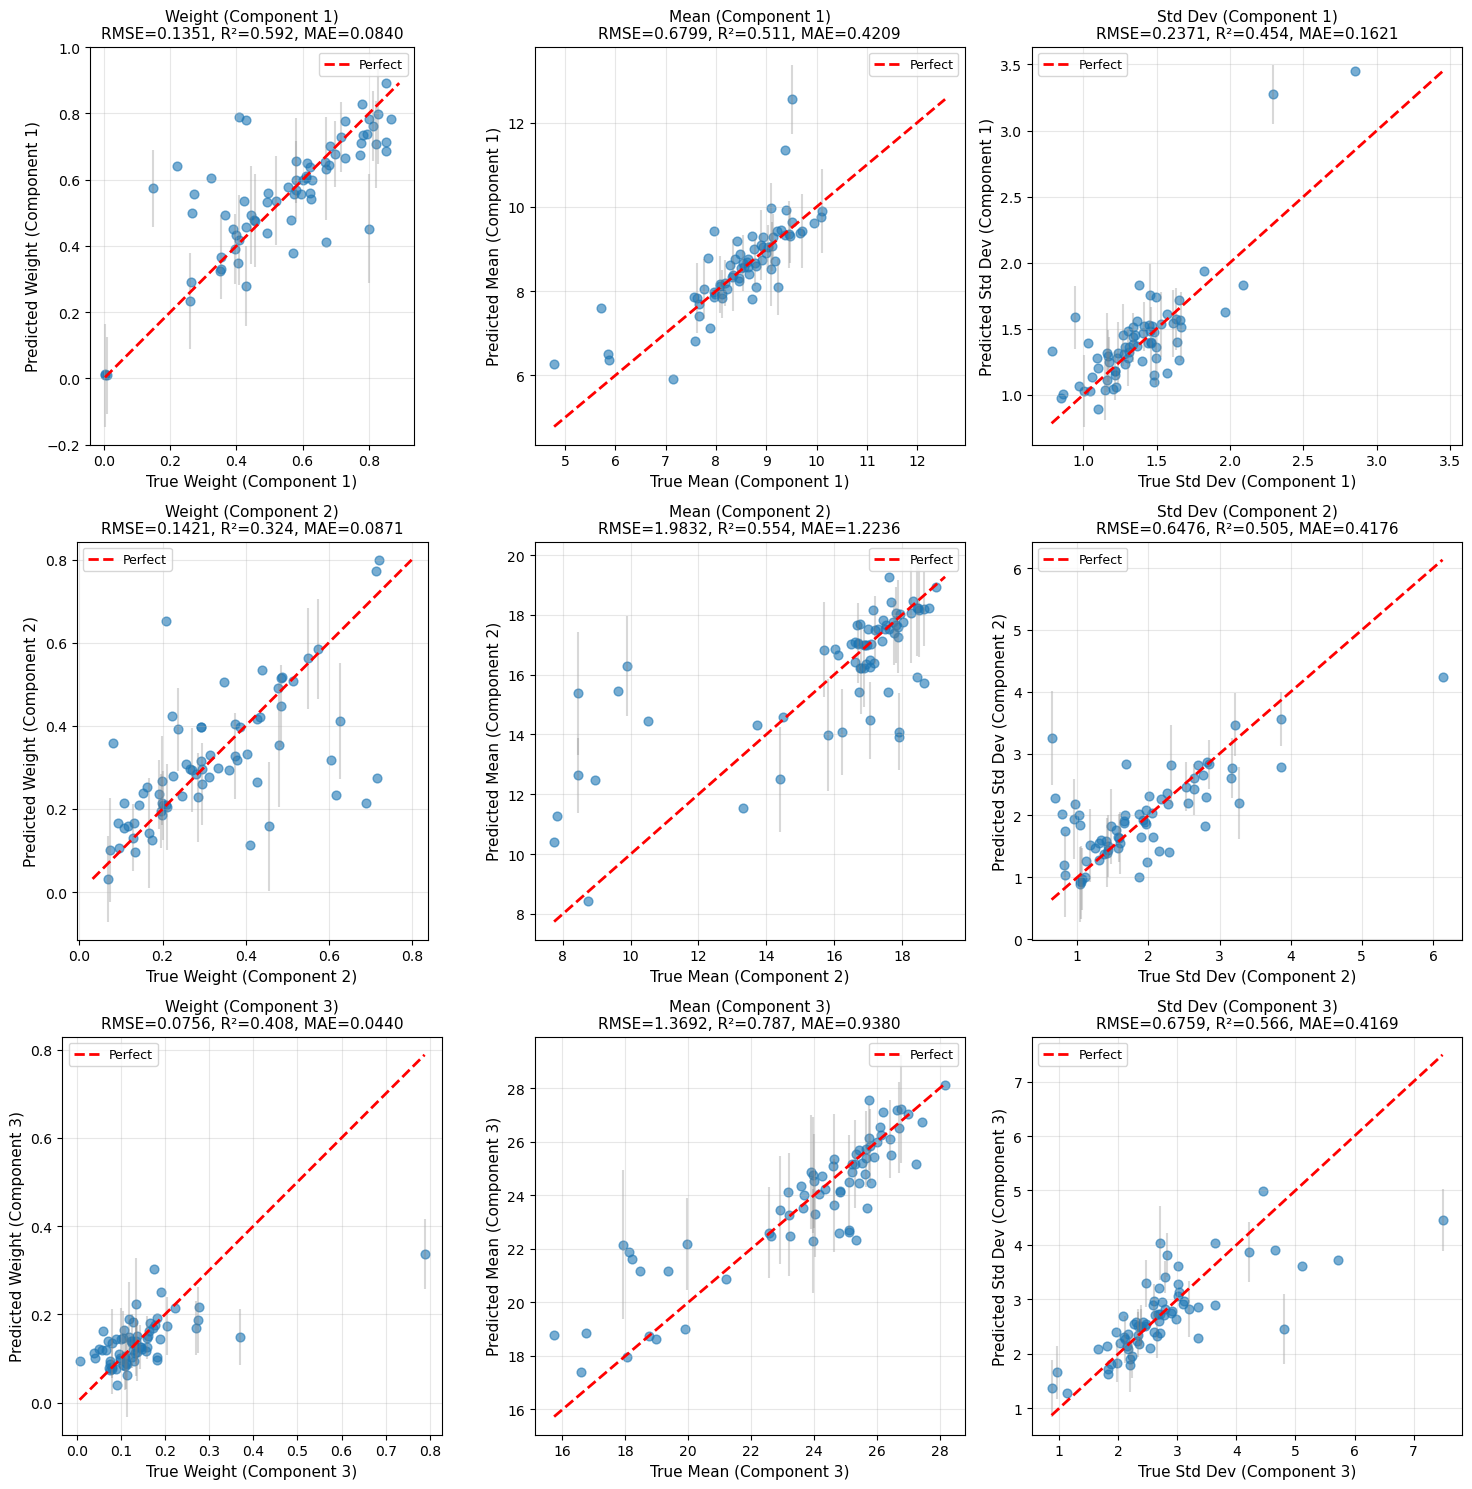

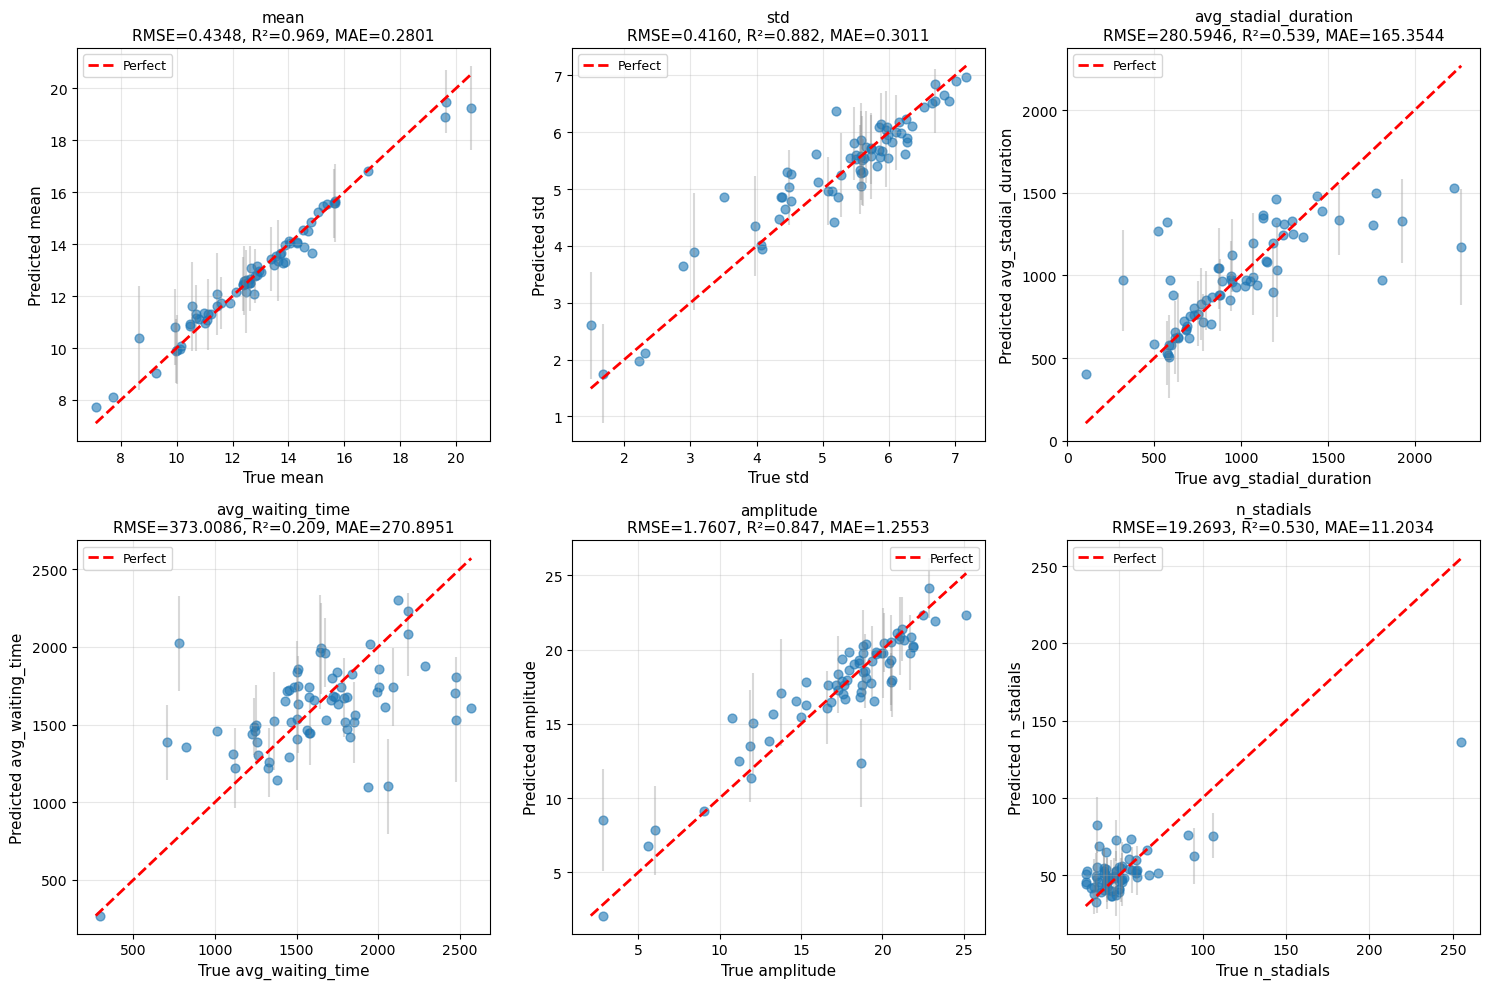

TypeError: 'Axes' object is not subscriptable

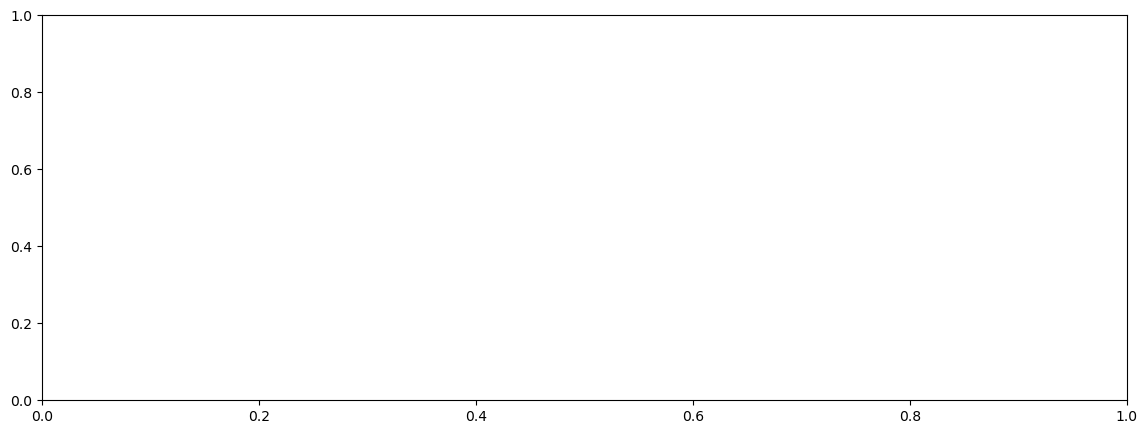

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import norm
import numpy as np

def plot_gmm_parameter_predictions(gp_emul, gmm_test, gmm_pred, gmm_std=None, save_prefix=None):
    """
    Plot true vs predicted for all GMM parameters.
    
    Parameters
    ----------
    gp_emul : GPEmulatorGMM
        Fitted GP emulator
    gmm_test : array, shape (n_samples, 3*n_components)
        True GMM parameters
    gmm_pred : array, shape (n_samples, 3*n_components)
        Predicted GMM parameters
    gmm_std : array, optional, shape (n_samples, 3*n_components)
        Prediction uncertainties
    save_prefix : str, optional
        If provided, saves figure as {save_prefix}_gmm_params.png
    """
    n_components = gp_emul.n_components
    n_params = 3 * n_components
    
    # Create subplots: one row per component, 3 columns (w, mu, sigma)
    fig, axes = plt.subplots(n_components, 3, figsize=(15, 5 * n_components))
    
    # Handle single component case
    if n_components == 1:
        axes = axes.reshape(1, -1)
    
    param_types = ['Weight', 'Mean', 'Std Dev']
    
    for comp in range(n_components):
        for param_type in range(3):  # 0=weight, 1=mean, 2=std
            idx = comp * 3 + param_type
            ax = axes[comp, param_type]
            
            true_vals = gmm_test[:, idx]
            pred_vals = gmm_pred[:, idx]
            
            # Scatter plot
            ax.scatter(true_vals, pred_vals, alpha=0.6, s=40)
            
            # Perfect prediction line
            min_val = min(true_vals.min(), pred_vals.min())
            max_val = max(true_vals.max(), pred_vals.max())
            ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
                   linewidth=2, label='Perfect', zorder=5)
            
            # Add error bars if uncertainties provided
            if gmm_std is not None:
                uncertainties = gmm_std[:, idx]
                # Sample a subset for clarity
                n_errorbar_samples = min(20, len(true_vals))
                sample_indices = np.random.choice(len(true_vals), n_errorbar_samples, replace=False)
                ax.errorbar(true_vals[sample_indices], pred_vals[sample_indices], 
                           yerr=uncertainties[sample_indices], 
                           fmt='none', ecolor='gray', alpha=0.3, zorder=1)
            
            # Compute metrics
            rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
            r2 = r2_score(true_vals, pred_vals)
            mae = np.mean(np.abs(true_vals - pred_vals))
            
            # Labels and title
            param_name = f'{param_types[param_type]} (Component {comp+1})'
            ax.set_xlabel(f'True {param_name}', fontsize=11)
            ax.set_ylabel(f'Predicted {param_name}', fontsize=11)
            ax.set_title(f'{param_name}\nRMSE={rmse:.4f}, R²={r2:.3f}, MAE={mae:.4f}', 
                        fontsize=11)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
            
            # Add 1:1 aspect for weights
            if param_type == 0:
                ax.set_aspect('equal', adjustable='box')
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_gmm_params.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_summary_statistics(Y_test, Y_pred, Y_std=None, stat_names=None, save_prefix=None):
    """
    Plot true vs predicted for all other summary statistics.
    
    Parameters
    ----------
    Y_test : array, shape (n_samples, n_stats)
        True summary statistics
    Y_pred : array, shape (n_samples, n_stats)
        Predicted summary statistics
    Y_std : array, optional, shape (n_samples, n_stats)
        Prediction uncertainties
    stat_names : list of str, optional
        Names of the statistics. If None, uses generic names
    save_prefix : str, optional
        If provided, saves figure
    """
    n_stats = Y_test.shape[1]
    
    if stat_names is None:
        stat_names = [f'Stat {i+1}' for i in range(n_stats)]
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = int(np.ceil(n_stats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_stats > 1 else [axes]
    
    for i in range(n_stats):
        ax = axes[i]
        
        true_vals = Y_test[:, i]
        pred_vals = Y_pred[:, i]
        
        # Scatter plot
        ax.scatter(true_vals, pred_vals, alpha=0.6, s=40)
        
        # Perfect prediction line
        min_val = min(true_vals.min(), pred_vals.min())
        max_val = max(true_vals.max(), pred_vals.max())
        ax.plot([min_val, max_val], [min_val, max_val], 'r--', 
               linewidth=2, label='Perfect', zorder=5)
        
        # Add error bars if uncertainties provided
        if Y_std is not None:
            uncertainties = Y_std[:, i]
            # Sample a subset for clarity
            n_errorbar_samples = min(20, len(true_vals))
            sample_indices = np.random.choice(len(true_vals), n_errorbar_samples, replace=False)
            ax.errorbar(true_vals[sample_indices], pred_vals[sample_indices], 
                       yerr=uncertainties[sample_indices], 
                       fmt='none', ecolor='gray', alpha=0.3, zorder=1)
        
        # Compute metrics
        rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
        r2 = r2_score(true_vals, pred_vals)
        mae = np.mean(np.abs(true_vals - pred_vals))
        
        # Labels and title
        ax.set_xlabel(f'True {stat_names[i]}', fontsize=11)
        ax.set_ylabel(f'Predicted {stat_names[i]}', fontsize=11)
        ax.set_title(f'{stat_names[i]}\nRMSE={rmse:.4f}, R²={r2:.3f}, MAE={mae:.4f}', 
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_stats, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_summary_stats.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_summary_stats_uncertainty_calibration(Y_test, Y_pred, Y_std, stat_names=None, save_prefix=None):
    """
    Plot prediction error vs uncertainty for summary statistics.
    
    Parameters
    ----------
    Y_test : array
        True summary statistics
    Y_pred : array
        Predicted summary statistics
    Y_std : array
        Prediction uncertainties
    stat_names : list of str, optional
        Names of the statistics
    save_prefix : str, optional
        If provided, saves figure
    """
    n_stats = Y_test.shape[1]
    
    if stat_names is None:
        stat_names = [f'Stat {i+1}' for i in range(n_stats)]
    
    # Calculate grid dimensions
    n_cols = 3
    n_rows = int(np.ceil(n_stats / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten() if n_stats > 1 else [axes]
    
    for i in range(n_stats):
        ax = axes[i]
        
        errors = np.abs(Y_test[:, i] - Y_pred[:, i])
        uncertainties = Y_std[:, i]
        
        # Scatter plot
        ax.scatter(uncertainties, errors, alpha=0.6, s=40)
        
        # Ideal calibration line (error = uncertainty)
        max_val = max(uncertainties.max(), errors.max())
        ax.plot([0, max_val], [0, max_val], 'r--', 
               linewidth=2, label='Perfect calibration')
        
        # Compute calibration metric: fraction within 1-sigma
        within_1sigma = np.sum(errors <= uncertainties) / len(errors)
        
        ax.set_xlabel(f'Predicted Std ({stat_names[i]})', fontsize=11)
        ax.set_ylabel(f'Absolute Error ({stat_names[i]})', fontsize=11)
        ax.set_title(f'{stat_names[i]}\n{within_1sigma:.1%} within 1σ', 
                    fontsize=11)
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    # Hide unused subplots
    for i in range(n_stats, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_summary_stats_uncertainty.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_gmm_uncertainty_calibration(gp_emul, gmm_test, gmm_pred, gmm_std, save_prefix=None):
    """
    Plot prediction error vs uncertainty for calibration assessment.
    
    Parameters
    ----------
    gp_emul : GPEmulatorGMM
        Fitted GP emulator
    gmm_test : array
        True GMM parameters
    gmm_pred : array
        Predicted GMM parameters
    gmm_std : array
        Prediction uncertainties
    save_prefix : str, optional
        If provided, saves figure
    """
    n_components = gp_emul.n_components
    
    fig, axes = plt.subplots(n_components, 3, figsize=(15, 5 * n_components))
    
    if n_components == 1:
        axes = axes.reshape(1, -1)
    
    param_types = ['Weight', 'Mean', 'Std Dev']
    
    for comp in range(n_components):
        for param_type in range(3):
            idx = comp * 3 + param_type
            ax = axes[comp, param_type]
            
            errors = np.abs(gmm_test[:, idx] - gmm_pred[:, idx])
            uncertainties = gmm_std[:, idx]
            
            # Scatter plot
            ax.scatter(uncertainties, errors, alpha=0.6, s=40)
            
            # Ideal calibration line (error = uncertainty)
            max_val = max(uncertainties.max(), errors.max())
            ax.plot([0, max_val], [0, max_val], 'r--', 
                   linewidth=2, label='Perfect calibration')
            
            # Compute calibration metric: fraction within 1-sigma
            within_1sigma = np.sum(errors <= uncertainties) / len(errors)
            
            param_name = f'{param_types[param_type]} (C{comp+1})'
            ax.set_xlabel(f'Predicted Std ({param_name})', fontsize=11)
            ax.set_ylabel(f'Absolute Error ({param_name})', fontsize=11)
            ax.set_title(f'{param_name}\n{within_1sigma:.1%} within 1σ', 
                        fontsize=11)
            ax.legend(fontsize=9)
            ax.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_gmm_uncertainty_calibration.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_weight_constraints(gp_emul, gmm_test, gmm_pred, save_prefix=None):
    """
    Analyze weight constraint satisfaction.
    
    Parameters
    ----------
    gp_emul : GPEmulatorGMM
        Fitted GP emulator
    gmm_test : array
        True GMM parameters
    gmm_pred : array
        Predicted GMM parameters
    save_prefix : str, optional
        If provided, saves figure
    """
    n_components = gp_emul.n_components
    
    # Extract all weights
    weight_indices = [i * 3 for i in range(n_components)]
    weights_test = gmm_test[:, weight_indices]
    weights_pred = gmm_pred[:, weight_indices]
    
    # Sum of weights
    w_sum_test = weights_test.sum(axis=1)
    w_sum_pred = weights_pred.sum(axis=1)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Plot 1: Weight sum distribution
    axes[0].hist(w_sum_test, bins=30, alpha=0.6, label='True (test set)', 
                edgecolor='black', color='blue')
    axes[0].hist(w_sum_pred, bins=30, alpha=0.6, label='Predicted', 
                edgecolor='black', color='red')
    axes[0].axvline(1.0, color='green', linestyle='--', linewidth=2, 
                   label='Target sum = 1')
    axes[0].set_xlabel('Sum of weights')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Weight Constraint Satisfaction\n'
                     f'True mean: {w_sum_test.mean():.4f}, '
                     f'Pred mean: {w_sum_pred.mean():.4f}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Plot 2: Individual weights distribution
    for i in range(n_components):
        axes[1].hist(weights_test[:, i], bins=20, alpha=0.4, 
                    label=f'True C{i+1}', edgecolor='black')
        axes[1].hist(weights_pred[:, i], bins=20, alpha=0.4, 
                    label=f'Pred C{i+1}', edgecolor='black', linestyle='--')
    axes[1].set_xlabel('Weight value')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Individual Weights')
    axes[1].legend(fontsize=8)
    axes[1].grid(alpha=0.3)
    
    # Plot 3: Weight simplex (only works well for 2-3 components)
    if n_components == 2:
        axes[2].scatter(weights_test[:, 0], weights_test[:, 1], 
                       c='blue', alpha=0.5, s=40, label='True')
        axes[2].scatter(weights_pred[:, 0], weights_pred[:, 1], 
                       c='red', alpha=0.5, s=40, label='Predicted')
        axes[2].plot([0, 1], [1, 0], 'k--', alpha=0.5, label='w₁+w₂=1')
        axes[2].set_xlabel('w₁')
        axes[2].set_ylabel('w₂')
        axes[2].set_title('Weight Space (2 components)')
        axes[2].legend()
        axes[2].grid(alpha=0.3)
        axes[2].set_aspect('equal')
    elif n_components == 3:
        # Ternary-like projection: plot w1 vs w2, color by w3
        sc_test = axes[2].scatter(weights_test[:, 0], weights_test[:, 1], 
                                 c=weights_test[:, 2], cmap='Blues', 
                                 alpha=0.5, s=40, label='True', vmin=0, vmax=1)
        sc_pred = axes[2].scatter(weights_pred[:, 0], weights_pred[:, 1], 
                                 c=weights_pred[:, 2], cmap='Reds', 
                                 alpha=0.5, s=40, label='Predicted', vmin=0, vmax=1)
        axes[2].set_xlabel('w₁')
        axes[2].set_ylabel('w₂')
        axes[2].set_title('Weight Space (w₃ shown by color)')
        plt.colorbar(sc_pred, ax=axes[2], label='w₃')
        axes[2].legend()
        axes[2].grid(alpha=0.3)
    else:
        # For >3 components, show correlation matrix
        import seaborn as sns
        corr_test = np.corrcoef(weights_test.T)
        sns.heatmap(corr_test, annot=True, fmt='.2f', ax=axes[2], 
                   cmap='coolwarm', center=0, vmin=-1, vmax=1,
                   xticklabels=[f'w{i+1}' for i in range(n_components)],
                   yticklabels=[f'w{i+1}' for i in range(n_components)])
        axes[2].set_title('Weight Correlation Matrix (True)')
    
    plt.tight_layout()
    
    if save_prefix:
        plt.savefig(f'{save_prefix}_weight_constraints.png', dpi=150, bbox_inches='tight')
    
    plt.show()


def plot_pdf_samples(gp_emul, gmm_test, gmm_pred, pdf_test, pdf_pred, 
                     n_samples=6, save_prefix=None):
    """
    Plot sample PDF reconstructions with component breakdown.
    
    Parameters
    ----------
    gp_emul : GPEmulatorGMM
        Fitted GP emulator
    gmm_test : array
        True GMM parameters
    gmm_pred : array
        Predicted GMM parameters
    pdf_test : array
        True PDFs
    pdf_pred : array
        Predicted PDFs
    n_samples : int
        Number of samples to plot
    save_prefix : str, optional
        If provided, saves figures
    """
    x_grid = gp_emul.pdf_xpoints
    n_components = gp_emul.n_components
    colors = plt.cm.tab10(np.linspace(0, 1, n_components))
    
    n_samples = min(n_samples, len(gmm_test))
    
    for sample_idx in range(n_samples):
        fig, axes = plt.subplots(1, 1, figsize=(14, 5))
        
        # Left: PDF comparison
        axes[0].plot(x_grid, pdf_test[sample_idx], label='True PDF', 
                    linewidth=1.5, color='black')
        axes[0].plot(x_grid, pdf_pred[sample_idx], label='Predicted PDF', 
                    linestyle='--', linewidth=1.5, color='red')
        axes[0].fill_between(x_grid, pdf_test[sample_idx], pdf_pred[sample_idx], 
                            alpha=0.3, color='gray')
        
        rmse = np.sqrt(np.mean((pdf_test[sample_idx] - pdf_pred[sample_idx])**2))
        axes[0].set_xlabel('AMOC (Sv)', fontsize=12)
        axes[0].set_ylabel('Density', fontsize=12)
        axes[0].set_title(f'Sample {sample_idx} - PDF Comparison\nRMSE: {rmse:.4f}', 
                         fontsize=13)
        axes[0].legend(fontsize=11)
        axes[0].grid(alpha=0.3)
        
        # Right: GMM components breakdown
        # Get component parameters
        components_test = gp_emul.get_component_params(gmm_test[sample_idx])
        components_pred = gp_emul.get_component_params(gmm_pred[sample_idx])
        
        # Plot predicted components (filled)
        for j, (w, mu, sigma) in enumerate(components_pred):
            component_pdf = w * norm.pdf(x_grid, mu, sigma)
            axes[1].fill_between(x_grid, component_pdf, alpha=0.3, color=colors[j],
                                label=f'Pred C{j+1}: w={w:.2f}')
        
        # Plot true components (dashed lines)
        for j, (w_true, mu_true, sigma_true) in enumerate(components_test):
            component_pdf_true = w_true * norm.pdf(x_grid, mu_true, sigma_true)
            axes[1].plot(x_grid, component_pdf_true, 
                        color=colors[j], linestyle='--', alpha=0.8, linewidth=1,
                        label=f'True C{j+1}: w={w_true:.2f}')
        '''
        # Plot totals
        axes[1].plot(x_grid, pdf_pred[sample_idx], 'r-', linewidth=1.5, 
                    label='Total (pred)', zorder=10)
        axes[1].plot(x_grid, pdf_test[sample_idx], 'k--', linewidth=1.5, 
                    alpha=0.7, label='Total (true)', zorder=10)
        
        axes[1].set_xlabel('AMOC (Sv)', fontsize=12)
        axes[1].set_ylabel('Density', fontsize=12)
        axes[1].set_title(f'Sample {sample_idx} - GMM Components', 
                         fontsize=13)
        axes[1].legend(fontsize=8, loc='best', ncol=2)
        axes[1].grid(alpha=0.3)
        '''
        
        plt.tight_layout()
        
        if save_prefix:
            plt.savefig(f'{save_prefix}_sample_{sample_idx}.png', 
                       dpi=150, bbox_inches='tight')
        
        plt.show()


def print_summary_statistics(gp_emul, gmm_test, gmm_pred, pdf_test, pdf_pred, 
                            Y_test, Y_pred, stat_names=None):
    """
    Print comprehensive summary statistics.
    
    Parameters
    ----------
    gp_emul : GPEmulatorGMM
        Fitted GP emulator
    gmm_test : array
        True GMM parameters
    gmm_pred : array
        Predicted GMM parameters
    pdf_test : array
        True PDFs
    pdf_pred : array
        Predicted PDFs
    Y_test : array
        True summary statistics
    Y_pred : array
        Predicted summary statistics
    stat_names : list of str, optional
        Names of summary statistics
    """
    n_components = gp_emul.n_components
    
    print("=" * 70)
    print(f"GMM EMULATOR EVALUATION SUMMARY ({n_components} components)")
    print("=" * 70)
    
    # Overall GMM parameter metrics
    gmm_rmse = np.sqrt(mean_squared_error(gmm_test, gmm_pred))
    gmm_r2 = r2_score(gmm_test.flatten(), gmm_pred.flatten())
    print(f"\nOverall GMM parameters:")
    print(f"  RMSE: {gmm_rmse:.4f}")
    print(f"  R²:   {gmm_r2:.4f}")
    
    # Per-parameter metrics
    print(f"\nIndividual parameter metrics:")
    param_types = ['w', 'μ', 'σ']
    
    for comp in range(n_components):
        print(f"\n  Component {comp + 1}:")
        for param_type_idx, param_type in enumerate(param_types):
            idx = comp * 3 + param_type_idx
            rmse = np.sqrt(mean_squared_error(gmm_test[:, idx], gmm_pred[:, idx]))
            r2 = r2_score(gmm_test[:, idx], gmm_pred[:, idx])
            mae = np.mean(np.abs(gmm_test[:, idx] - gmm_pred[:, idx]))
            print(f"    {param_type}: RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")
    
    # Weight constraint satisfaction
    weight_indices = [i * 3 for i in range(n_components)]
    w_sum_test = gmm_test[:, weight_indices].sum(axis=1)
    w_sum_pred = gmm_pred[:, weight_indices].sum(axis=1)
    
    print(f"\nWeight constraint satisfaction:")
    print(f"  True mean sum:      {w_sum_test.mean():.4f} ± {w_sum_test.std():.4f}")
    print(f"  Predicted mean sum: {w_sum_pred.mean():.4f} ± {w_sum_pred.std():.4f}")
    
    # PDF reconstruction metrics
    pdf_rmse = np.sqrt(mean_squared_error(pdf_test, pdf_pred))
    pdf_mae = np.mean(np.abs(pdf_test - pdf_pred))
    
    print(f"\nPDF reconstruction:")
    print(f"  RMSE: {pdf_rmse:.4f}")
    print(f"  MAE:  {pdf_mae:.4f}")
    
    # Summary statistics metrics
    if stat_names is None:
        stat_names = [f'Stat {i+1}' for i in range(Y_test.shape[1])]
    
    print(f"\nOther summary statistics:")
    for i, name in enumerate(stat_names):
        rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_pred[:, i]))
        r2 = r2_score(Y_test[:, i], Y_pred[:, i])
        mae = np.mean(np.abs(Y_test[:, i] - Y_pred[:, i]))
        print(f"  {name}: RMSE={rmse:.4f}, R²={r2:.4f}, MAE={mae:.4f}")
    
    print("=" * 70)


# ============================================================================
# MAIN USAGE
# ============================================================================

# After training and prediction:
# gmm_pred, Y_pred, gmm_std, Y_std = gp_emul.predict(X_test, return_std=True)
# pdf_test = gp_emul.reconstruct_pdf(gmm_test)
# pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)

# Define your summary statistic names
stat_names = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 'n_stadials']
# Add more if you have PSD bins, quantiles, etc.
# stat_names = ['mean', 'std', 'avg_stadial_duration', 'avg_waiting_time', 'amplitude', 
#               'psd_bin_1', 'psd_bin_2', ..., 'quantile_10', 'quantile_25', ...]

# Generate all plots
save_prefix = "gmm_emulator_results"  # or None to not save

print_summary_statistics(gp_emul, gmm_test, gmm_pred, pdf_test, pdf_pred,
                        Y_test, Y_pred, stat_names=stat_names)

# GMM parameter plots
plot_gmm_parameter_predictions(gp_emul, gmm_test, gmm_pred, gmm_std, 
                               save_prefix=save_prefix)

#plot_gmm_uncertainty_calibration(gp_emul, gmm_test, gmm_pred, gmm_std, 
#                                 save_prefix=save_prefix)

#plot_weight_constraints(gp_emul, gmm_test, gmm_pred, 
#                       save_prefix=save_prefix)

# Summary statistics plots
plot_summary_statistics(Y_test, Y_pred, Y_std, stat_names=stat_names,
                       save_prefix=save_prefix)

#plot_summary_stats_uncertainty_calibration(Y_test, Y_pred, Y_std, 
#                                          stat_names=stat_names,
#                                          save_prefix=save_prefix)

# PDF sample plots
plot_pdf_samples(gp_emul, gmm_test, gmm_pred, pdf_test, pdf_pred, 
                n_samples=6, save_prefix=save_prefix)

# MCMC

In [ ]:
import emcee
import numpy as np

# -----------------------------
# 1. Prior bounds (6 parameters)
# -----------------------------
prior_bounds = {
    "diff_dia_min": (7.5e-6, 1.25e-5),
    "drag_topo_fac": (2.25, 3.75),
    "slope_max": (7.5e-4, 1.25e-3),
    "diff_iso": (1125, 1875),
    "diff_gm": (1125, 1875),
    "diff_dia_max": (1.125e-4, 1.875e-4),
}
param_names = list(prior_bounds.keys())
lower_bounds = np.array([b[0] for b in prior_bounds.values()])
upper_bounds = np.array([b[1] for b in prior_bounds.values()])
ndim = len(param_names)

def log_prior(theta):
    theta = np.asarray(theta)
    if np.all((theta >= lower_bounds) & (theta <= upper_bounds)):
        return 0.0
    return -np.inf

# -----------------------------
# 2. Target statistics from observations/default run
# -----------------------------
# PDF target (from observations or default run)
pdf_target = default_stats_gmm['pdf']  # shape: (n_grid_points,)
x_grid = default_stats_gmm['x_grid']

# Other summary statistics targets
mean_target = default_stats_gmm['mean']
std_target = default_stats_gmm['std']
waiting_time_target = default_stats_gmm['avg_waiting_time']
stadial_duration_target = default_stats_gmm['avg_stadial_duration']
amplitude_target = default_stats_gmm['avg_amplitude']

# -----------------------------
# 3. Log-likelihood: PDF + other statistics
# -----------------------------
# Uncertainty parameters (tune these based on your emulator performance and data)
sigma_pdf = 0.01            # uncertainty per PDF point
sigma_mean = 0.5            # uncertainty in mean (Sv)
sigma_std = 0.3             # uncertainty in std (Sv)
sigma_waiting = 50.0        # uncertainty in waiting time (years)
sigma_stadial_dur = 50.0    # uncertainty in stadial duration (years)
sigma_amplitude = 1.0       # uncertainty in amplitude (Sv)

def log_likelihood(theta):
    """
    Compute log-likelihood for matching PDF and other summary statistics.
    
    The emulator predicts GMM parameters, which are then used to reconstruct the PDF.
    """
    theta = np.array(theta).reshape(1, -1)
    
    # Predict GMM parameters and other stats
    gmm_pred, Y_pred = gp_emul.predict(theta, return_std=False)
    
    # Reconstruct PDF from GMM parameters
    pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)
    pdf_pred = pdf_pred.flatten()
    
    # Extract other predicted statistics
    # Assuming Y contains: [mean, std, avg_stadial_duration, avg_waiting_time, amplitude]
    pred_mean = Y_pred[0, 0]
    pred_std = Y_pred[0, 1]
    pred_stadial_dur = Y_pred[0, 2]
    pred_waiting = Y_pred[0, 3]
    pred_amplitude = Y_pred[0, 4]
    
    # Gaussian discrepancy for PDF (sum over all grid points)
    pdf_term = -0.5 * np.sum((pdf_target - pdf_pred)**2) / sigma_pdf**2
    
    # Gaussian discrepancy for mean
    mean_term = -0.5 * (mean_target - pred_mean)**2 / sigma_mean**2
    
    # Gaussian discrepancy for standard deviation
    std_term = -0.5 * (std_target - pred_std)**2 / sigma_std**2
    
    # Gaussian discrepancy for waiting time
    waiting_term = -0.5 * (waiting_time_target - pred_waiting)**2 / sigma_waiting**2
    
    # Gaussian discrepancy for stadial duration
    stadial_dur_term = -0.5 * (stadial_duration_target - pred_stadial_dur)**2 / sigma_stadial_dur**2
    
    # Gaussian discrepancy for amplitude
    amplitude_term = -0.5 * (amplitude_target - pred_amplitude)**2 / sigma_amplitude**2
    
    # Combine all terms (you can comment out terms you don't want to use)
    log_like = pdf_term + waiting_term + std_term
    # log_like += mean_term  # uncomment if using
    # log_like += stadial_dur_term  # uncomment if using
    # log_like += amplitude_term  # uncomment if using
    
    return log_like


# Alternative: Weighted likelihood with tunable weights
def log_likelihood_weighted(theta, weights=None):
    """
    Weighted log-likelihood allowing control over importance of each component.
    
    Parameters:
    -----------
    theta : array
        Parameter values
    weights : dict, optional
        Weights for each component. Default: equal weights of 1.0
    """
    if weights is None:
        weights = {
            'pdf': 1.0,
            'mean': 0.0,           # disabled by default
            'std': 1.0,
            'waiting': 1.0,
            'stadial_dur': 0.0,    # disabled by default
            'amplitude': 0.0       # disabled by default
        }
    
    theta = np.array(theta).reshape(1, -1)
    
    # Predict GMM parameters and other stats
    gmm_pred, Y_pred = gp_emul.predict(theta, return_std=False)
    
    # Reconstruct PDF from GMM parameters
    pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)
    pdf_pred = pdf_pred.flatten()
    
    # Extract predictions
    pred_mean = Y_pred[0, 0]
    pred_std = Y_pred[0, 1]
    pred_stadial_dur = Y_pred[0, 2]
    pred_waiting = Y_pred[0, 3]
    pred_amplitude = Y_pred[0, 4]
    
    # Calculate individual terms
    pdf_term = -0.5 * np.sum((pdf_target - pdf_pred)**2) / sigma_pdf**2
    mean_term = -0.5 * (mean_target - pred_mean)**2 / sigma_mean**2
    std_term = -0.5 * (std_target - pred_std)**2 / sigma_std**2
    waiting_term = -0.5 * (waiting_time_target - pred_waiting)**2 / sigma_waiting**2
    stadial_dur_term = -0.5 * (stadial_duration_target - pred_stadial_dur)**2 / sigma_stadial_dur**2
    amplitude_term = -0.5 * (amplitude_target - pred_amplitude)**2 / sigma_amplitude**2
    
    # Apply weights
    log_like = (weights['pdf'] * pdf_term + 
                weights['mean'] * mean_term +
                weights['std'] * std_term + 
                weights['waiting'] * waiting_term +
                weights['stadial_dur'] * stadial_dur_term +
                weights['amplitude'] * amplitude_term)
    
    return log_like


# -----------------------------
# 4. Posterior function
# -----------------------------
def log_posterior(theta):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta)

# For weighted version:
def log_posterior_weighted(theta, weights=None):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood_weighted(theta, weights)


# -----------------------------
# 5. Initialize walkers
# -----------------------------
nwalkers = 32
initial_pos = lower_bounds + (upper_bounds - lower_bounds) * np.random.rand(nwalkers, ndim)

# -----------------------------
# 6. Run MCMC
# -----------------------------
print("Running MCMC with GMM-based PDF + summary statistics constraints...")
print(f"Target waiting time: {waiting_time_target:.1f} years")
print(f"Target std: {std_target:.2f} Sv")
print(f"Target mean: {mean_target:.2f} Sv")
print("="*60)

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_posterior)
n_steps = 7000
sampler.run_mcmc(initial_pos, n_steps, progress=True)

# -----------------------------
# 7. Extract posterior samples
# -----------------------------
burn_in = 1000
thin = 10
posterior_samples = sampler.get_chain(discard=burn_in, thin=thin, flat=True)
print(f"\nPosterior samples shape: {posterior_samples.shape}")

# -----------------------------
# 8. Analyze convergence
# -----------------------------
# Check acceptance fraction
acceptance = sampler.acceptance_fraction
print(f"\nMean acceptance fraction: {np.mean(acceptance):.3f}")
print(f"Acceptance fraction range: [{np.min(acceptance):.3f}, {np.max(acceptance):.3f}]")

# Autocorrelation time (if enough steps)
try:
    tau = sampler.get_autocorr_time(quiet=True)
    print(f"\nAutocorrelation time: {np.mean(tau):.1f} steps")
    print(f"Effective number of samples: {posterior_samples.shape[0] / np.mean(tau):.0f}")
except:
    print("\nCould not compute autocorrelation time (may need more steps)")

# -----------------------------
# 9. Posterior predictive check
# -----------------------------
# Sample random parameters from posterior
n_check = 100
random_idx = np.random.choice(len(posterior_samples), size=n_check, replace=False)
check_samples = posterior_samples[random_idx]

# Get predictions for these samples
pred_pdfs_list = []
pred_stats_list = []
pred_gmm_list = []

for theta in check_samples:
    theta_reshaped = theta.reshape(1, -1)
    gmm_pred, Y_pred = gp_emul.predict(theta_reshaped, return_std=False)
    pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)
    
    pred_pdfs_list.append(pdf_pred.flatten())
    pred_stats_list.append(Y_pred.flatten())
    pred_gmm_list.append(gmm_pred.flatten())

pred_pdfs_array = np.array(pred_pdfs_list)
pred_stats_array = np.array(pred_stats_list)
pred_gmm_array = np.array(pred_gmm_list)

# Print posterior predictive statistics
print("\n" + "="*60)
print("POSTERIOR PREDICTIVE CHECK")
print("="*60)
print(f"\nTarget values:")
print(f"  Mean: {mean_target:.2f} Sv")
print(f"  Std: {std_target:.2f} Sv")
print(f"  Waiting time: {waiting_time_target:.1f} years")
print(f"  Stadial duration: {stadial_duration_target:.1f} years")
print(f"  Amplitude: {amplitude_target:.2f} Sv")

print(f"\nPosterior predictions (mean ± std):")
print(f"  Mean: {pred_stats_array[:, 0].mean():.2f} ± {pred_stats_array[:, 0].std():.2f} Sv")
print(f"  Std: {pred_stats_array[:, 1].mean():.2f} ± {pred_stats_array[:, 1].std():.2f} Sv")
print(f"  Stadial duration: {pred_stats_array[:, 2].mean():.1f} ± {pred_stats_array[:, 2].std():.1f} years")
print(f"  Waiting time: {pred_stats_array[:, 3].mean():.1f} ± {pred_stats_array[:, 3].std():.1f} years")
print(f"  Amplitude: {pred_stats_array[:, 4].mean():.2f} ± {pred_stats_array[:, 4].std():.2f} Sv")

# PDF RMSE
pdf_rmse = np.sqrt(np.mean((pdf_target - pred_pdfs_array.mean(axis=0))**2))
print(f"\nPDF reconstruction:")
print(f"  RMSE (mean prediction): {pdf_rmse:.4f}")

# -----------------------------
# 10. Visualize results
# -----------------------------
import matplotlib.pyplot as plt
from scipy.stats import norm

# Trace plots
fig, axes = plt.subplots(ndim, 1, figsize=(10, 2*ndim))
samples = sampler.get_chain()
for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(param_names[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
axes[-1].set_xlabel("Step number")
plt.tight_layout()
plt.savefig('mcmc_traces.png', dpi=150, bbox_inches='tight')
plt.show()

# PDF comparison and statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top left: PDF comparison
ax = axes[0, 0]
# Plot posterior predictive distribution (median and uncertainty)
pred_pdf_median = np.median(pred_pdfs_array, axis=0)
pred_pdf_lower = np.percentile(pred_pdfs_array, 16, axis=0)
pred_pdf_upper = np.percentile(pred_pdfs_array, 84, axis=0)

ax.plot(x_grid, pdf_target, 'k-', linewidth=2.5, label='Target PDF', zorder=10)
ax.plot(x_grid, pred_pdf_median, 'r--', linewidth=2, label='Posterior Median')
ax.fill_between(x_grid, pred_pdf_lower, pred_pdf_upper, 
                alpha=0.3, color='red', label='68% Credible Interval')

# Plot individual posterior samples (light lines)
for i in range(min(20, len(pred_pdfs_list))):
    ax.plot(x_grid, pred_pdfs_list[i], 'r-', alpha=0.1, linewidth=0.5)

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('PDF: Target vs Posterior Predictive', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Top right: GMM components of median prediction
ax = axes[0, 1]
# Get median GMM parameters
gmm_median = np.median(pred_gmm_array, axis=0)
components = gp_emul.get_component_params(gmm_median)

colors = plt.cm.tab10(np.linspace(0, 1, gp_emul.n_components))
for j, (w, mu, sigma) in enumerate(components):
    component_pdf = w * norm.pdf(x_grid, mu, sigma)
    ax.fill_between(x_grid, component_pdf, alpha=0.3, color=colors[j],
                    label=f'C{j+1}: w={w:.2f}, μ={mu:.1f}, σ={sigma:.1f}')

ax.plot(x_grid, pdf_target, 'k-', linewidth=2.5, label='Target', zorder=10)
ax.plot(x_grid, pred_pdf_median, 'r--', linewidth=2, label='Posterior Median', zorder=9)

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('GMM Components (Median)', fontsize=13, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# Bottom left: Summary statistics comparison
ax = axes[1, 0]
stat_names = ['Mean', 'Std', 'Waiting\nTime', 'Stadial\nDuration', 'Amplitude']
target_vals = [mean_target, std_target, waiting_time_target, 
               stadial_duration_target, amplitude_target]
pred_means = [pred_stats_array[:, i].mean() for i in range(5)]
pred_stds = [pred_stats_array[:, i].std() for i in range(5)]

x_pos = np.arange(len(stat_names))
width = 0.35

ax.bar(x_pos - width/2, target_vals, width, label='Target', 
       color='black', alpha=0.6, edgecolor='black')
ax.bar(x_pos + width/2, pred_means, width, yerr=pred_stds, capsize=5,
       label='Posterior', color='red', alpha=0.6, edgecolor='black')

ax.set_xlabel('Statistic', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Summary Statistics: Target vs Posterior', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(stat_names, fontsize=10)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Bottom right: Parameter posterior distributions
ax = axes[1, 1]
# Show marginal distributions for first 3 parameters
n_show = min(3, ndim)
for i in range(n_show):
    ax.hist(posterior_samples[:, i], bins=30, alpha=0.5, 
            label=param_names[i], density=True)

ax.set_xlabel('Parameter Value', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Marginal Parameter Posteriors', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('mcmc_posterior_predictive.png', dpi=150, bbox_inches='tight')
plt.show()

# Corner plot (requires corner package)
try:
    import corner
    fig = corner.corner(posterior_samples, labels=param_names,
                       quantiles=[0.16, 0.5, 0.84],
                       show_titles=True, title_fmt='.4f')
    plt.savefig('mcmc_corner.png', dpi=150, bbox_inches='tight')
    plt.show()
except ImportError:
    print("\nInstall 'corner' package for corner plots: pip install corner")

print("\n" + "="*60)
print("MCMC COMPLETE")
print("="*60)
print(f"\nPosterior samples saved. Shape: {posterior_samples.shape}")
print(f"You can access them via: posterior_samples")

In [ ]:
theta_default = np.array([
    1e-05,      # diff_dia_min
    3.0,        # drag_topo_fac
    0.001,      # slope_max
    1500,       # diff_iso
    1500,       # diff_gm
    0.00015     # diff_dia_max
])

# -----------------------------
# Draw samples from posterior and get predictions
# -----------------------------
n_posterior_samples = 1000  # Number of samples to draw from posterior
random_idx = np.random.choice(len(posterior_samples), size=n_posterior_samples, replace=False)
sampled_params = posterior_samples[random_idx]

# Get predictions for all sampled parameters
pred_pdfs_list = []
pred_stats_list = []
pred_gmm_list = []

print(f"Drawing {n_posterior_samples} samples from posterior and making predictions...")
for theta in sampled_params:
    theta_reshaped = theta.reshape(1, -1)
    gmm_pred, pred_stats = gp_emul.predict(theta_reshaped, return_std=False)
    pdf_pred = gp_emul.reconstruct_pdf(gmm_pred)
    pred_pdfs_list.append(pdf_pred.flatten())
    pred_stats_list.append(pred_stats.flatten())
    pred_gmm_list.append(gmm_pred.flatten())

pred_pdfs_array = np.array(pred_pdfs_list)  # shape: (n_samples, n_grid_points)
pred_stats_array = np.array(pred_stats_list)  # shape: (n_samples, 6)
pred_gmm_array = np.array(pred_gmm_list)  # shape: (n_samples, 9)

# -----------------------------
# Combined plot: Parameters + Predictions
# -----------------------------
from scipy.stats import gaussian_kde

# Define target values
target_values = [
    default_stats_gmm['mean'],
    default_stats_gmm['std'],
    default_stats_gmm['avg_stadial_duration'],
    default_stats_gmm['avg_waiting_time'],
    default_stats_gmm['avg_amplitude'],
    default_stats_gmm['n_stadials']
]

# Extract bounds for plotting
bounds = [(lower_bounds[i], upper_bounds[i]) for i in range(ndim)]
n_params = len(param_names)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(n_params, 2, hspace=0.3, wspace=0.3)

# Left column: Parameter posteriors
for j in range(n_params):
    ax = fig.add_subplot(gs[j, 0])
    lb, ub = bounds[j]
    
    # KDE for parameter posterior
    data_param = posterior_samples[:, j]
    kde_param = gaussian_kde(data_param)
    x_vals = np.linspace(lb, ub, 500)
    y_vals_param = kde_param(x_vals)
    
    ax.plot(x_vals, y_vals_param, color='orange', linewidth=2, label='Posterior')
    ax.fill_between(x_vals, y_vals_param, alpha=0.3, color='orange')
    
    # Prior bounds
    ax.axvline(lb, color='#696969', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.axvline(ub, color='#696969', linestyle='--', alpha=0.6, linewidth=1.5)
    
    # Default parameter
    default_val = theta_default[j]
    ax.axvline(default_val, color='red', linestyle='-', alpha=0.6, 
              linewidth=1.5, label='Default')
    
    ax.set_xlim(lb, ub)
    ax.set_ylabel(param_names[j], rotation=0, ha='right', va='center', fontsize=10)
    ax.yaxis.set_label_coords(-0.15, 0.5)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    if j == 0:
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title('Parameter Posteriors', fontweight='bold', fontsize=12)

# Right column: Predicted statistics (select key ones)
# pred_stats format: [mean, std, avg_stadial_duration, avg_waiting_time, avg_amplitude, n_stadials]
key_stats = [1, 3, 2, 4]  # std, waiting_time, stadial_duration, amplitude
key_names = ['Std (Sv)', 'Waiting Time (years)', 
             'Stadial Duration (years)', 'Amplitude (Sv)']

for idx, (stat_idx, stat_name) in enumerate(zip(key_stats, key_names)):
    ax = fig.add_subplot(gs[idx, 1])
    
    data_posterior = pred_stats_array[:, stat_idx]
    target_val = target_values[stat_idx]
    
    data_min = np.min(data_posterior)
    data_max = np.max(data_posterior)
    data_range = data_max - data_min
    lb_plot = data_min - 0.2 * data_range
    ub_plot = data_max + 0.2 * data_range
    
    if np.std(data_posterior) > 0:
        kde_posterior = gaussian_kde(data_posterior)
        x_vals = np.linspace(lb_plot, ub_plot, 500)
        y_vals_posterior = kde_posterior(x_vals)
        ax.plot(x_vals, y_vals_posterior, color='blue', linewidth=2, 
               label='Predicted')
        ax.fill_between(x_vals, y_vals_posterior, alpha=0.3, color='blue')
    
    ax.axvline(target_val, color='red', linestyle='-', linewidth=2.5, 
              label='Target', alpha=0.8)
    
    ax.set_xlim(lb_plot, ub_plot)
    ax.set_ylabel(stat_name, rotation=0, ha='right', va='center', fontsize=10)
    ax.yaxis.set_label_coords(-0.3, 0.5)
    ax.set_yticks([])
    ax.grid(axis='x', alpha=0.3)
    if idx == 0:
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title('Predicted Statistics', fontweight='bold', fontsize=12)

plt.suptitle(f'MCMC Calibration Results - GMM Emulator ({n_posterior_samples} posterior samples)', 
            fontsize=14, fontweight='bold')
plt.savefig('mcmc_calibration_combined_gmm.pdf', dpi=300, bbox_inches='tight')
print("Combined figure saved to: mcmc_calibration_combined_gmm.pdf")
plt.show()

# -----------------------------
# Additional: PDF overlay plot
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 6))

# Plot target PDF
ax.plot(x_grid, pdf_target, 'k-', linewidth=3, label='Target', zorder=10)

# Plot posterior predictive PDFs (sample)
n_plot_samples = min(200, len(pred_pdfs_array))
sample_indices = np.random.choice(len(pred_pdfs_array), n_plot_samples, replace=False)

for i in sample_indices:
    ax.plot(x_grid, pred_pdfs_array[i], 'b-', alpha=0.02, linewidth=0.5)

# Plot median and credible intervals
pdf_median = np.median(pred_pdfs_array, axis=0)
pdf_lower = np.percentile(pred_pdfs_array, 16, axis=0)
pdf_upper = np.percentile(pred_pdfs_array, 84, axis=0)

ax.plot(x_grid, pdf_median, 'b-', linewidth=2, label='Posterior Median', zorder=9)
ax.fill_between(x_grid, pdf_lower, pdf_upper, alpha=0.3, color='blue', 
                label='68% Credible Interval', zorder=8)

ax.set_xlabel('AMOC (Sv)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'PDF: Target vs Posterior Predictive - GMM ({n_posterior_samples} samples)', 
            fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('mcmc_pdf_overlay_gmm.pdf', dpi=300, bbox_inches='tight')
print("PDF overlay saved to: mcmc_pdf_overlay_gmm.pdf")
plt.show()

# -----------------------------
# GMM-specific: Component parameter distributions
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
gmm_param_names = ['w₁', 'μ₁', 'σ₁', 'w₂', 'μ₂', 'σ₂', 'w₃', 'μ₃', 'σ₃']

for i, (ax, param_name) in enumerate(zip(axes.flat, gmm_param_names)):
    data = pred_gmm_array[:, i]
    
    # Histogram
    ax.hist(data, bins=40, alpha=0.6, color='steelblue', edgecolor='black', density=True)
    
    # KDE overlay
    if np.std(data) > 0:
        kde = gaussian_kde(data)
        x_vals = np.linspace(data.min(), data.max(), 200)
        ax.plot(x_vals, kde(x_vals), 'r-', linewidth=2, label='KDE')
    
    # Statistics
    mean_val = np.mean(data)
    median_val = np.median(data)
    ax.axvline(mean_val, color='orange', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.3f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.3f}')
    
    ax.set_xlabel(param_name, fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{param_name} Posterior Distribution', fontsize=12)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle(f'GMM Component Parameter Posteriors ({n_posterior_samples} samples)', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mcmc_gmm_parameter_posteriors.pdf', dpi=300, bbox_inches='tight')
print("GMM parameter posteriors saved to: mcmc_gmm_parameter_posteriors.pdf")
plt.show()

# -----------------------------
# GMM weight constraint visualization
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Check weight sum
w_sum = pred_gmm_array[:, 0] + pred_gmm_array[:, 3] + pred_gmm_array[:, 6]

# Plot 1: Weight sum histogram
axes[0].hist(w_sum, bins=40, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(1.0, color='red', linestyle='--', linewidth=2, label='Target sum = 1')
axes[0].axvline(np.mean(w_sum), color='orange', linestyle='--', linewidth=2, 
                label=f'Mean: {np.mean(w_sum):.4f}')
axes[0].set_xlabel('Sum of weights (w₁ + w₂ + w₃)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Weight Constraint Satisfaction', fontsize=12)
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# Plot 2: Ternary-style (w1 vs w2)
axes[1].scatter(pred_gmm_array[:, 0], pred_gmm_array[:, 3], 
                c=pred_gmm_array[:, 6], cmap='viridis', alpha=0.5, s=10)
axes[1].set_xlabel('w₁', fontsize=11)
axes[1].set_ylabel('w₂', fontsize=11)
axes[1].set_title('Weight Distribution (colored by w₃)', fontsize=12)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('w₃', fontsize=10)
axes[1].grid(alpha=0.3)

# Plot 3: All three weights as box plots
weight_data = [pred_gmm_array[:, 0], pred_gmm_array[:, 3], pred_gmm_array[:, 6]]
bp = axes[2].boxplot(weight_data, labels=['w₁', 'w₂', 'w₃'], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[2].set_ylabel('Weight value', fontsize=11)
axes[2].set_title('Weight Distribution Comparison', fontsize=12)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle(f'GMM Weight Analysis ({n_posterior_samples} samples)', 
            fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mcmc_gmm_weights.pdf', dpi=300, bbox_inches='tight')
print("GMM weight analysis saved to: mcmc_gmm_weights.pdf")
plt.show()

# -----------------------------
# Summary statistics table
# -----------------------------
print("\n" + "="*70)
print("POSTERIOR PREDICTIVE SUMMARY")
print("="*70)

stat_names_full = ['Mean', 'Std', 'Stadial Duration', 'Waiting Time', 'Amplitude', 'N Stadials']

print(f"\n{'Statistic':<25} {'Target':<15} {'Pred Mean':<15} {'Pred Std':<15} {'Coverage':<10}")
print("-"*80)

for i, name in enumerate(stat_names_full):
    target = target_values[i]
    pred_mean = np.mean(pred_stats_array[:, i])
    pred_std = np.std(pred_stats_array[:, i])
    
    # Check if target is within 1 std of prediction
    within_1std = abs(target - pred_mean) <= pred_std
    coverage = "✓" if within_1std else "✗"
    
    print(f"{name:<25} {target:<15.3f} {pred_mean:<15.3f} {pred_std:<15.3f} {coverage:<10}")

# PDF summary
pdf_rmse_per_sample = np.sqrt(np.mean((pdf_target - pred_pdfs_array)**2, axis=1))
pdf_rmse_mean = np.mean(pdf_rmse_per_sample)
pdf_rmse_std = np.std(pdf_rmse_per_sample)

print(f"\n{'PDF RMSE':<25} {'-':<15} {pdf_rmse_mean:<15.4f} {pdf_rmse_std:<15.4f}")

# GMM parameter summary
print(f"\n{'GMM Parameter':<25} {'Mean':<15} {'Std':<15} {'Min':<15} {'Max':<15}")
print("-"*80)
for i, name in enumerate(gmm_param_names):
    mean_val = np.mean(pred_gmm_array[:, i])
    std_val = np.std(pred_gmm_array[:, i])
    min_val = np.min(pred_gmm_array[:, i])
    max_val = np.max(pred_gmm_array[:, i])
    print(f"{name:<25} {mean_val:<15.4f} {std_val:<15.4f} {min_val:<15.4f} {max_val:<15.4f}")

print(f"\n{'Weight sum (w₁+w₂+w₃)':<25} {np.mean(w_sum):<15.4f} {np.std(w_sum):<15.4f} " +
      f"{np.min(w_sum):<15.4f} {np.max(w_sum):<15.4f}")

print("="*70)

# -----------------------------
# Quantify improvement over default
# -----------------------------
print("\n" + "="*70)
print("IMPROVEMENT OVER DEFAULT PARAMETERS")
print("="*70)

# Predict with default parameters
gmm_default, stats_default_pred = gp_emul.predict(theta_default.reshape(1, -1), return_std=False)
pdf_default_pred = gp_emul.reconstruct_pdf(gmm_default).flatten()

# Default errors
pdf_rmse_default = np.sqrt(np.mean((pdf_target - pdf_default_pred)**2))

print(f"\nPDF RMSE:")
print(f"  Default parameters: {pdf_rmse_default:.4f}")
print(f"  Posterior mean:     {pdf_rmse_mean:.4f}")
improvement_pdf = (1 - pdf_rmse_mean/pdf_rmse_default)*100 if pdf_rmse_default > 0 else 0
print(f"  Improvement:        {improvement_pdf:.1f}%")

print(f"\nSummary Statistics Errors (MAE):")
for i, name in enumerate(stat_names_full):
    target = target_values[i]
    default_error = abs(target - stats_default_pred[0, i])
    posterior_error = np.mean(np.abs(target - pred_stats_array[:, i]))
    improvement = (1 - posterior_error/default_error)*100 if default_error > 0 else 0
    
    print(f"  {name:<25} Default: {default_error:>8.3f}  Posterior: {posterior_error:>8.3f}  " +
          f"Improvement: {improvement:>6.1f}%")

print("="*70)

# -----------------------------
# Example GMM decompositions
# -----------------------------
from scipy.stats import norm

# Find best, median, and worst fits
pdf_rmse_all = np.sqrt(np.mean((pdf_target - pred_pdfs_array)**2, axis=1))
idx_best = np.argmin(pdf_rmse_all)
idx_median = np.argmin(np.abs(pdf_rmse_all - np.median(pdf_rmse_all)))
idx_worst = np.argmax(pdf_rmse_all)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, idx, label in zip(axes, [idx_best, idx_median, idx_worst], 
                          ['Best Fit', 'Median Fit', 'Worst Fit']):
    gmm_sample = pred_gmm_array[idx]
    pdf_sample = pred_pdfs_array[idx]
    rmse_sample = pdf_rmse_all[idx]
    
    # Extract GMM parameters (with w3 recalculated)
    w1, mu1, sig1, w2, mu2, sig2, w3_raw, mu3, sig3 = gmm_sample
    w3 = 1 - w1 - w2
    w3 = np.clip(w3, 0.0, 1.0)
    
    # Plot individual components
    ax.fill_between(x_grid, w1 * norm.pdf(x_grid, mu1, sig1), 
                    alpha=0.3, color='blue', label=f'C1: w={w1:.3f}')
    ax.fill_between(x_grid, w2 * norm.pdf(x_grid, mu2, sig2), 
                    alpha=0.3, color='green', label=f'C2: w={w2:.3f}')
    ax.fill_between(x_grid, w3 * norm.pdf(x_grid, mu3, sig3), 
                    alpha=0.3, color='orange', label=f'C3: w={w3:.3f}')
    
    # Plot total
    ax.plot(x_grid, pdf_sample, 'r-', linewidth=2, label='Total (pred)')
    ax.plot(x_grid, pdf_target, 'k--', linewidth=2, alpha=0.7, label='Target')
    
    ax.set_xlabel('AMOC (Sv)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{label}\nRMSE: {rmse_sample:.4f}', fontsize=12)
    ax.legend(fontsize=8, loc='best')
    ax.grid(alpha=0.3)

plt.suptitle('GMM Decomposition Examples from Posterior', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mcmc_gmm_examples.pdf', dpi=300, bbox_inches='tight')
print("GMM decomposition examples saved to: mcmc_gmm_examples.pdf")
plt.show()

# -----------------------------
# Correlation between GMM parameters
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Plot correlations between key GMM parameters
param_pairs = [
    (1, 4, 'μ₁', 'μ₂'),  # mu1 vs mu2
    (2, 5, 'σ₁', 'σ₂'),  # sig1 vs sig2
    (0, 3, 'w₁', 'w₂'),  # w1 vs w2
    (4, 7, 'μ₂', 'μ₃'),  # mu2 vs mu3
]

for ax, (idx1, idx2, name1, name2) in zip(axes.flat, param_pairs):
    data1 = pred_gmm_array[:, idx1]
    data2 = pred_gmm_array[:, idx2]
    
    # Scatter with density coloring
    h = ax.hexbin(data1, data2, gridsize=30, cmap='Blues', mincnt=1)
    ax.set_xlabel(name1, fontsize=11)
    ax.set_ylabel(name2, fontsize=11)
    
    # Compute correlation
    corr = np.corrcoef(data1, data2)[0, 1]
    ax.set_title(f'{name1} vs {name2} (r={corr:.3f})', fontsize=12)
    
    plt.colorbar(h, ax=ax, label='Count')
    ax.grid(alpha=0.3)

plt.suptitle('GMM Parameter Correlations', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mcmc_gmm_correlations.pdf', dpi=300, bbox_inches='tight')
print("GMM parameter correlations saved to: mcmc_gmm_correlations.pdf")
plt.show()

# -----------------------------
# Final summary
# -----------------------------
print("\n" + "="*70)
print("MCMC ANALYSIS COMPLETE")
print("="*70)
print(f"\nFiles saved:")
print(f"  1. mcmc_calibration_combined_gmm.pdf")
print(f"  2. mcmc_pdf_overlay_gmm.pdf")
print(f"  3. mcmc_gmm_parameter_posteriors.pdf")
print(f"  4. mcmc_gmm_weights.pdf")
print(f"  5. mcmc_gmm_examples.pdf")
print(f"  6. mcmc_gmm_correlations.pdf")
print("="*70)